# Generate Cluster Table

Bottom-up construction of the TESS cluster data table.

**Steps:**
1. Build base table from Wainer 2023 catalogs (name, age, origin)
2. Expand into one row per distinct sector combination; compute LC + LSP per row
3. Add variability summary statistics
4. (Follow-up) Add GP information
5. Save table to disk

In [1]:
# import os

# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = "1"
# os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
import sys, os

# Ensure GenerateTable_CGW is on the path so sub-packages resolve
MODULE_DIR = os.path.dirname(os.path.abspath('generate_table.ipynb'))
if MODULE_DIR not in sys.path:
    sys.path.insert(0, MODULE_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = '../data'
LC_DIR   = '../light_curves'
OUTPUT   = 'cluster_table_1sector2cadence_per_cluster.pkl'

In [4]:
print('MODULE_DIR: ', MODULE_DIR)
print('DATA_DIR  : ', DATA_DIR)
print('LC_DIR    : ', LC_DIR)
print('OUTPUT    : ', OUTPUT)

MODULE_DIR:  /astro/users/cgwill/TESS_Cluster_Age_ML/GenerateTable_CGW
DATA_DIR  :  ../data
LC_DIR    :  ../light_curves
OUTPUT    :  cluster_table_test.pkl


## Step 1 — Base table (name / age / origin)

In [5]:
from table_pipeline.wainer_table import build_base_table

base_table = build_base_table(DATA_DIR)
print(f"Total clusters: {len(base_table)}")
base_table.head()

  MW: 124 clusters from Wainer2023_Table1_MW.txt
  SMC: 106 clusters from Wainer2023_Table2_SMC.txt
  LMC: 118 clusters from Wainer2023_Table3_LMC.txt
[build_base_table] total: 348 clusters
Total clusters: 348


,name,age,origin
0,ASCC 116,7.95,MW
1,ASCC 57,9.26,MW
2,ASCC 8,7.77,MW
3,ASCC 81,8.75,MW
4,ASCC 9,7.00,MW


## Steps 2 / 2.5 / 2.75 — Expand by sector combos + LC + LSP

For each cluster:
- Discovers sectors in the FITS file
- Groups by cadence (no combo mixes different cadences)
- Generates distinct sector combinations via `make_distinct_sector_combinations`
- Loads, resamples, and normalizes the LC for each combo
- Computes LSP per combo

**This step is slow** — runs through all clusters. Adjust `f_max` to control combo density.

In [6]:
%%time
from table_pipeline.sector_expansion import expand_table

full_table = expand_table(
    base_table,
    lc_dir=LC_DIR,
    f_max=0.0,
    seed=0,
    shuffle=False,
    include_full=True,

    P_min=(30/60/24)*4, 
    P_max=10.0,
    
    n_wn_boot=200, #Computes the WN threshold in addition to FAP for use in the GP fitting step.
    wn_percentile=99.0,
    alpha=10,

    n_workers=16,
    
 )

print(f"Expanded table: {len(full_table)} rows")
print(f"Columns: {list(full_table.columns)}")
full_table[['name', 'age', 'origin', 'sectors', 'n_sectors', 'cadence']].head(10)

[expand_table] 348 clusters  |  n_workers=16
  [1/348] [BERKELEY 43]  (MW)  → 1 sectors, 1 cadence group(s), 1 combos
  [2/348] [ASCC 9]  (MW)  → 1 sectors, 1 cadence group(s), 1 combos
  [3/348] [BERKELEY 82]  (MW)  → 1 sectors, 1 cadence group(s), 1 combos
  [4/348] [BERKELEY 44]  (MW)  → 2 sectors, 2 cadence group(s), 2 combos
  [5/348] [BERKELEY 49]  (MW)  → 2 sectors, 2 cadence group(s), 2 combos
  [6/348] [BERKELEY 84]  (MW)  → 2 sectors, 2 cadence group(s), 2 combos
  [7/348] [COLLINDER 62]  (MW)  → 1 sectors, 1 cadence group(s), 1 combos
  [8/348] [ASCC 81]  (MW)  → 2 sectors, 2 cadence group(s), 2 combos
  [9/348] [ASCC 8]  (MW)  → 2 sectors, 2 cadence group(s), 2 combos
  [10/348] [DOLIDZE 3]  (MW)  → 1 sectors, 1 cadence group(s), 1 combos
  [11/348] [COLLINDER 307]  (MW)  → 2 sectors, 2 cadence group(s), 2 combos
  [12/348] [COLLINDER 261]  (MW)  → 2 sectors, 2 cadence group(s), 2 combos
  [13/348] [DBSB 159]  (MW)  → 2 sectors, 2 cadence group(s), 2 combos
  [14/348] [FSR 

,name,age,origin,sectors,n_sectors,cadence
0,BERKELEY 43,8.785,MW,[0],1,10.00
1,ASCC 9,7.000,MW,[0],1,30.00
2,BERKELEY 82,8.060,MW,[0],1,10.00
3,BERKELEY 44,9.150,MW,[0],1,30.00
4,BERKELEY 44,9.150,MW,[1],1,10.00
5,BERKELEY 49,8.460,MW,[0],1,30.00
6,BERKELEY 49,8.460,MW,[1],1,10.00
7,BERKELEY 84,8.080,MW,[0],1,30.00
8,BERKELEY 84,8.080,MW,[1],1,10.00
9,COLLINDER 62,8.905,MW,[0],1,3.33


In [63]:
full_table.head(1)

,name,age,origin,sectors,n_sectors,cadence,LC_t,LC_flux,LC_flux_err,LSP_freq,LSP_power,LSP_FAP,LSP_WN_threshold,LSP_red_noise_params
0,BERKELEY 43,8.785,MW,[0],1,10.0,"[2769.9179055011896, 2769.9387389694225, 2769....","[0.9997542559173304, 1.0000070871176017, 1.000...","[2.2310572709575515e-05, 2.23089394961062e-05,...","[0.1015168251649078, 0.1065926664231532, 0.111...","[1.111608150648219, 0.9988997034430155, 1.7636...",261.691612,11.4376,"(1.9352733185499902, 0.5385407471597276, 1.004..."


In [65]:
print('hi')

hi


In [21]:
# Full Table
#table = copy.deepcopy(full_table)

# Only sector per cluster 
#filtered = full_table[full_table['n_sectors'] == 1]
#table = filtered.groupby('name').sample(1)

# Only sector of a subset of clusters
# filtered = full_table[full_table['n_sectors'] == 1]
# filtered = filtered.groupby('name').sample(1)
# table = filtered.sample(n=10)

# Only sector of a subset of clusters which includes the high-variability ones
# filtered = full_table[full_table['n_sectors'] == 1]
# filtered = filtered.groupby('name').sample(1)
# must_have = ['BERKELEY 83', 'CZERNIK 13', 'KMHK1378']
# fixed = filtered[filtered['name'].isin(must_have)]
# rest = filtered[~filtered['name'].isin(must_have)].sample(n=7)
# table = pd.concat([fixed, rest])

# select 2 rows for each cluster, both rows being 1 sector data, but each of a different 'cadence'. 
#if no 2 cadences exist, use 2 of a single cadence
filtered = full_table[full_table['n_sectors'] == 1]
def pick_two(group):
    cadences = group['cadence'].unique()
    if len(cadences) >= 2:
        # one from each of two different cadences
        return group.groupby('cadence').sample(1).head(2)
    else:
        # two from the same cadence
        return group.sample(n=min(2, len(group)))
paired = filtered.groupby('name').apply(pick_two).reset_index(drop=True)
must_have = ['BERKELEY 83', 'CZERNIK 13', 'KMHK1378']
fixed = paired[paired['name'].isin(must_have)]
rest_names = paired[~paired['name'].isin(must_have)]['name'].unique()
rest_names = np.random.choice(rest_names, size=7, replace=False)
rest = paired[paired['name'].isin(rest_names)]
table = pd.concat([fixed, rest])

age 8.685


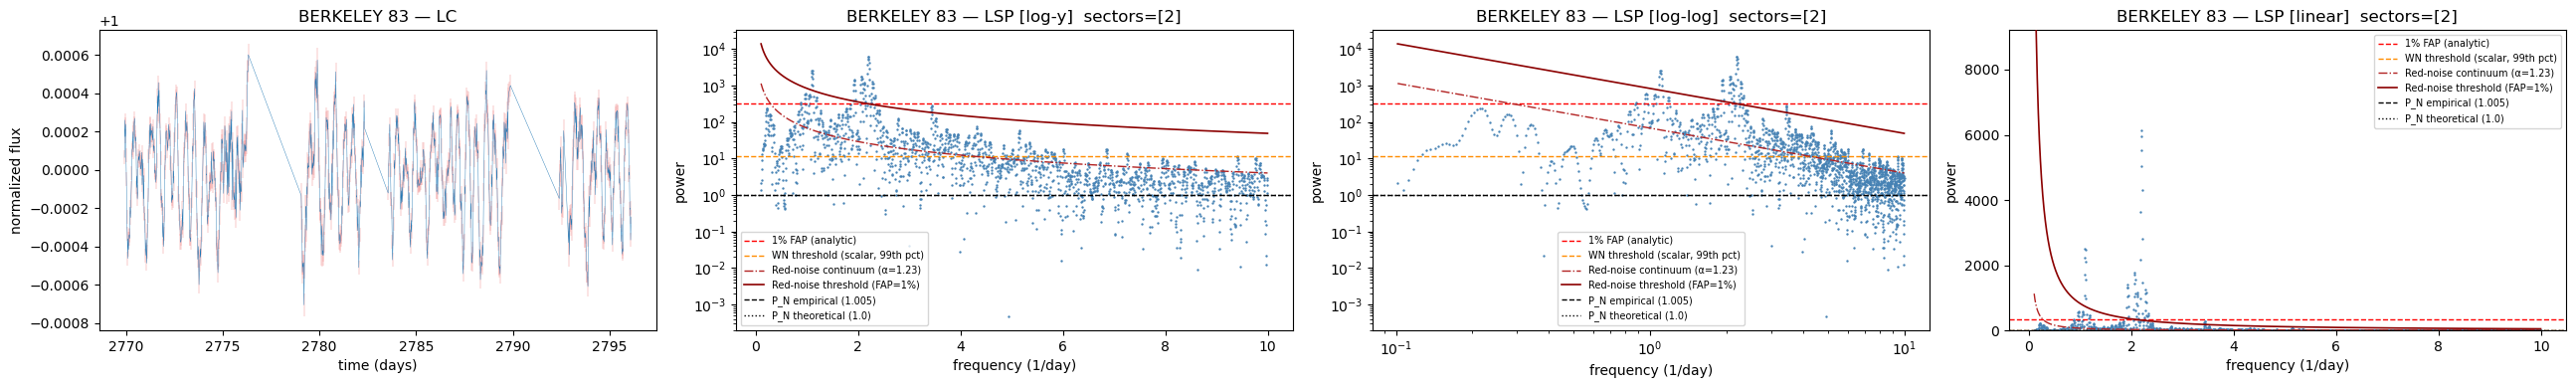

age 6.855


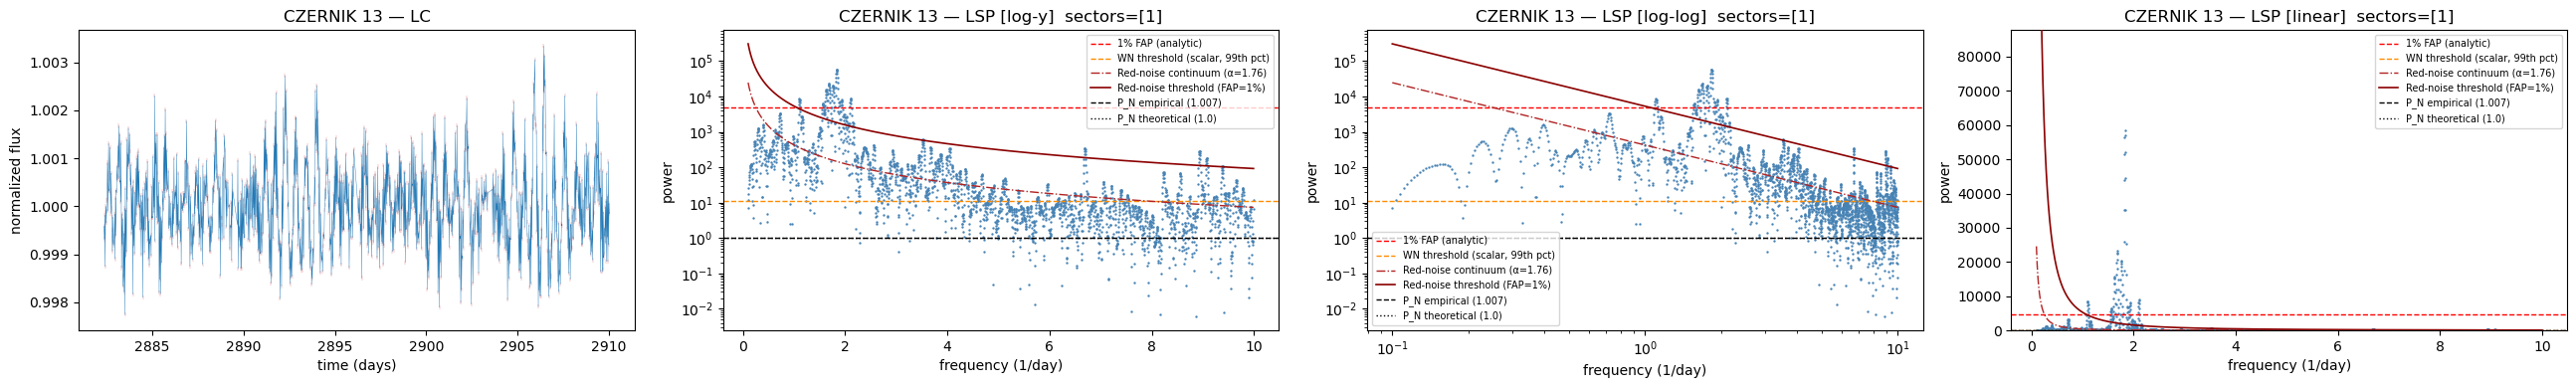

age 7.4


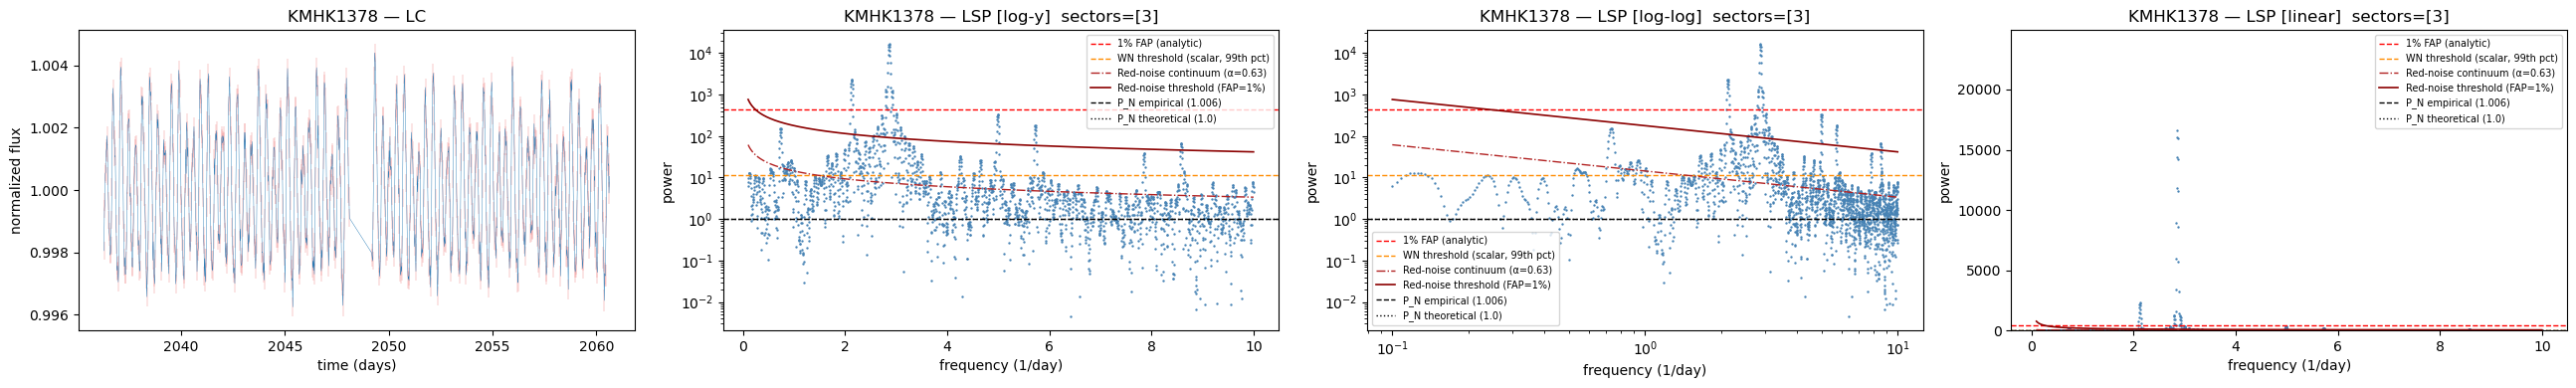

age 9.065


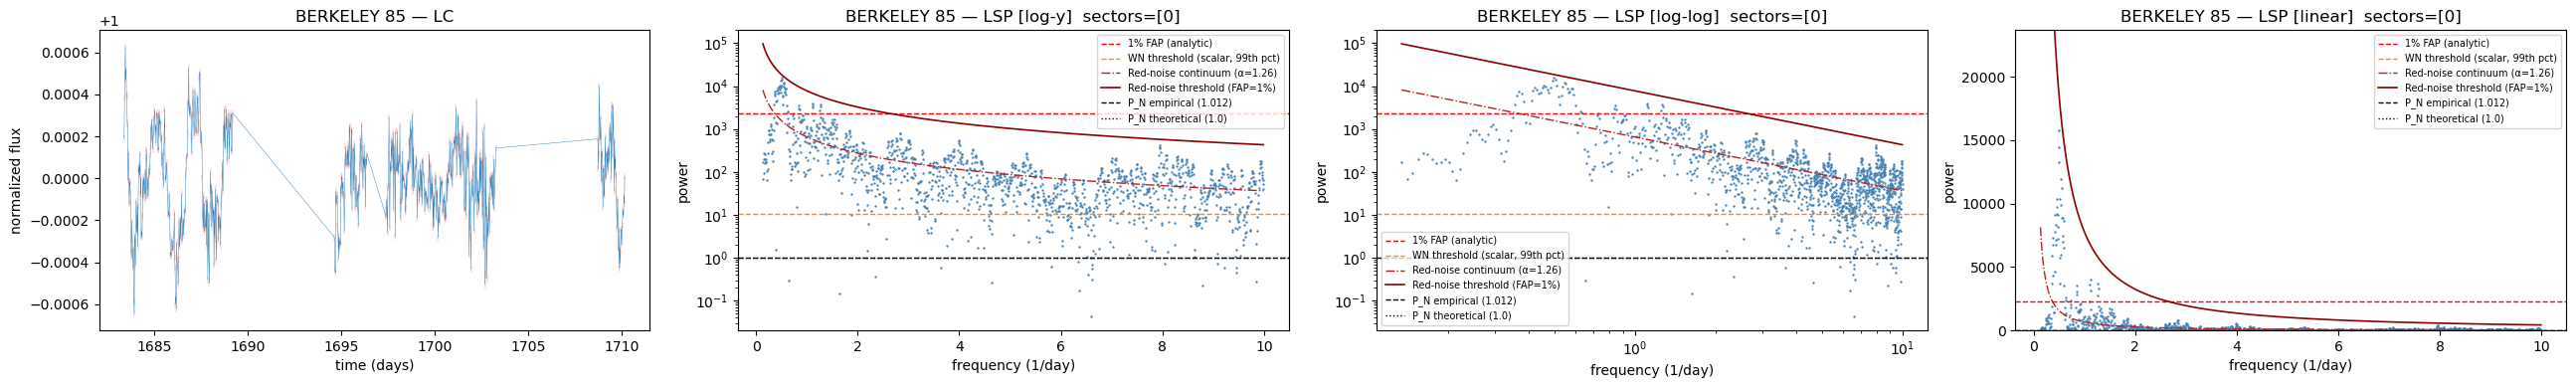

age 8.6


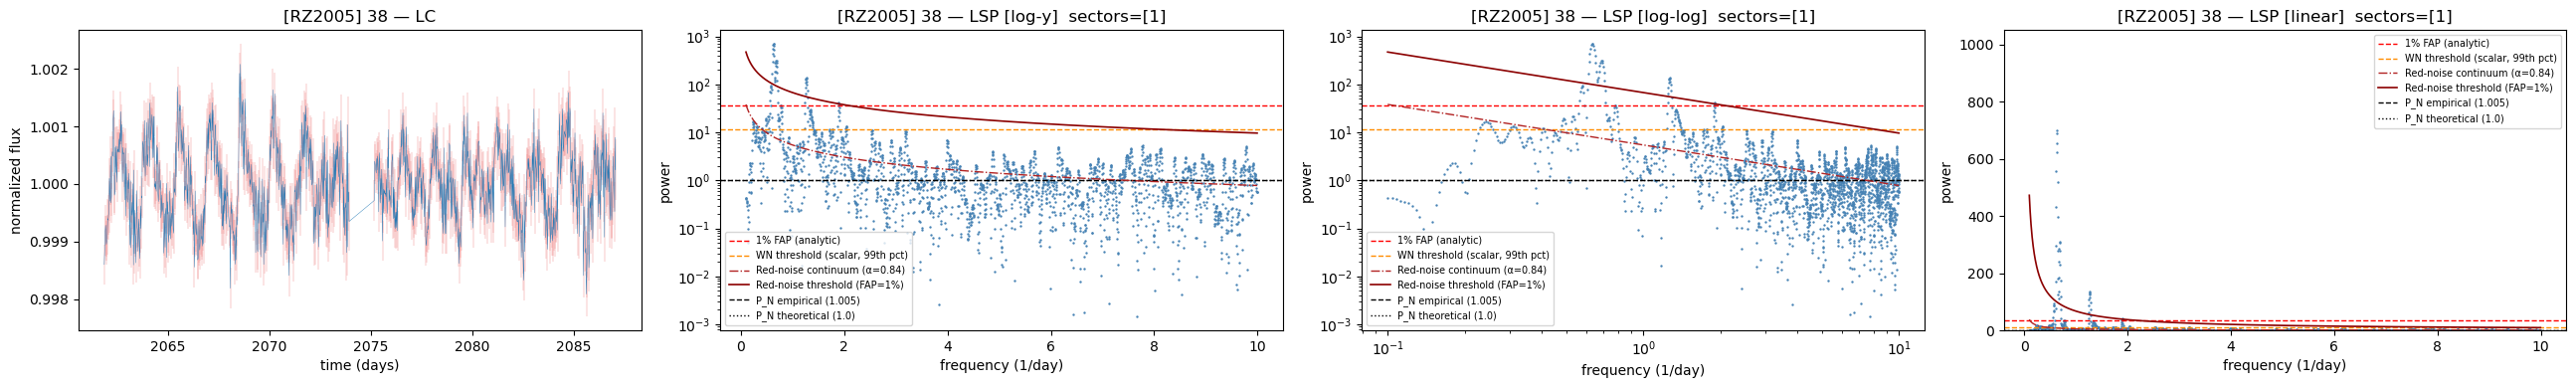

age 8.0


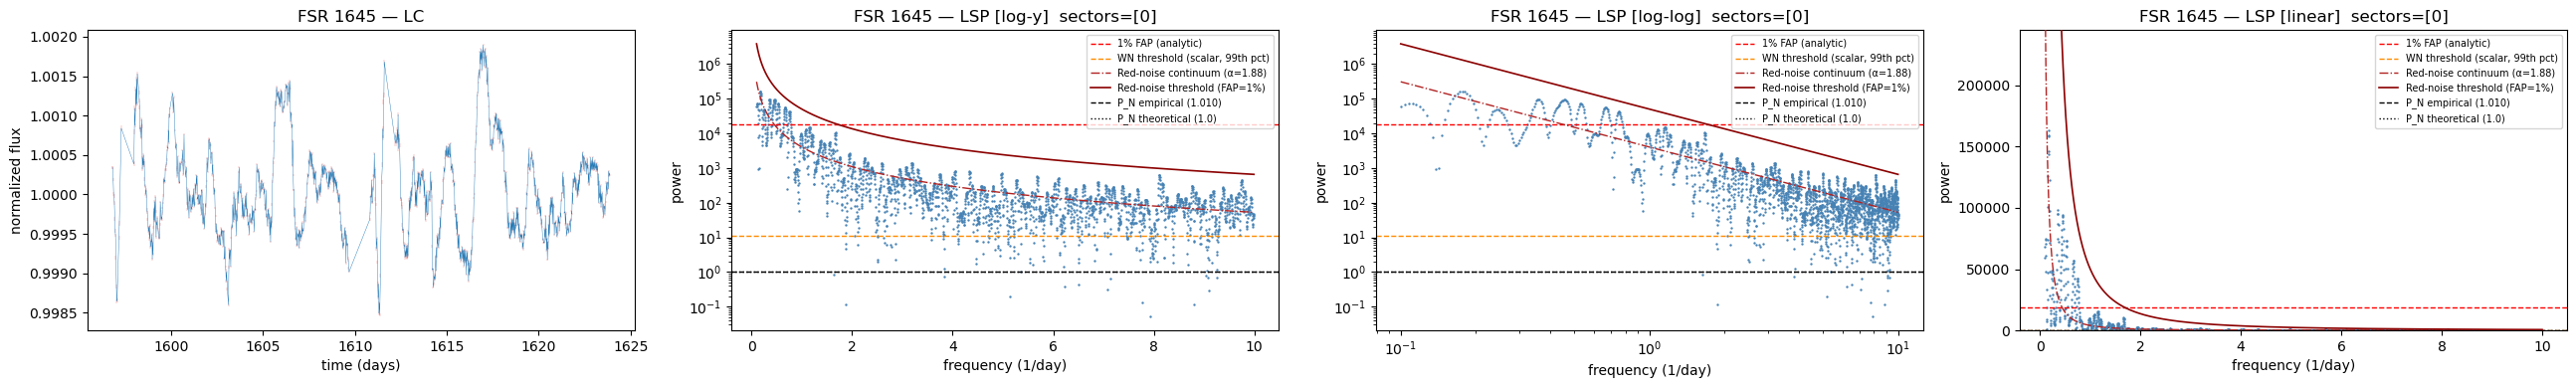

age 8.2


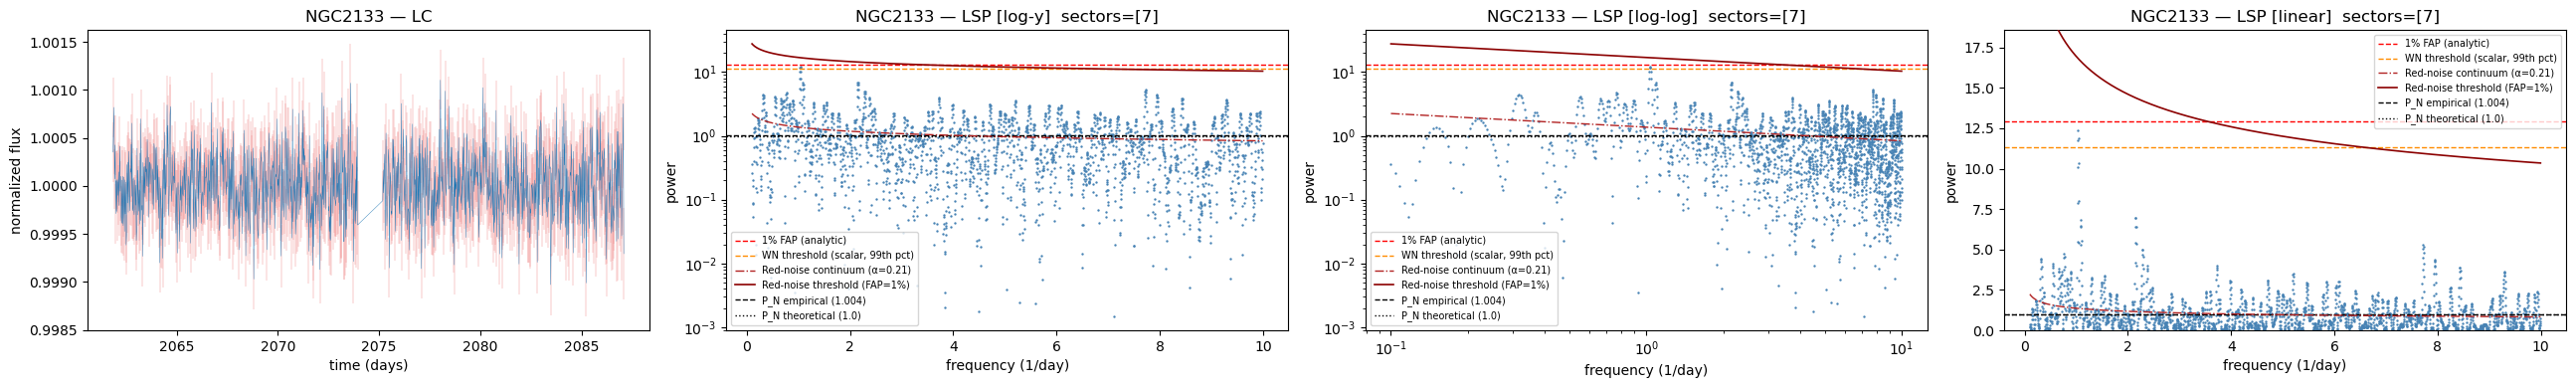

age 7.3


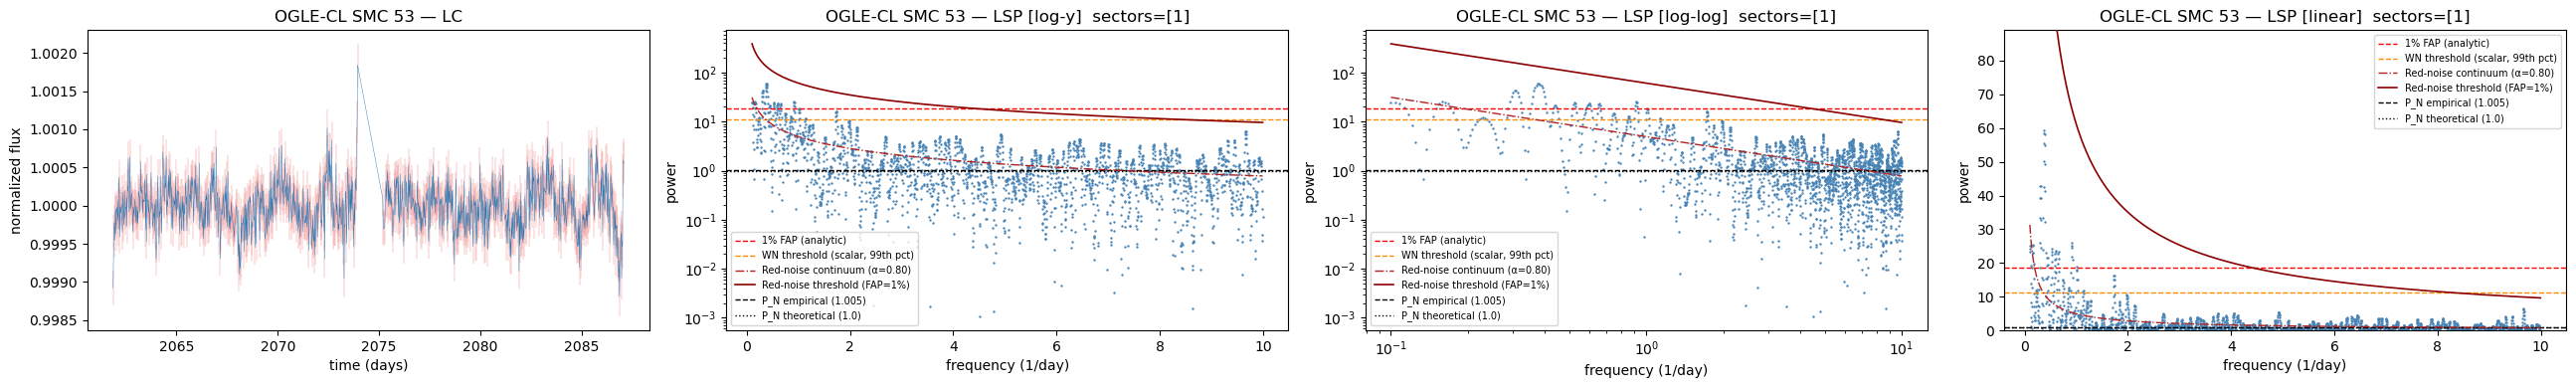

age 7.3


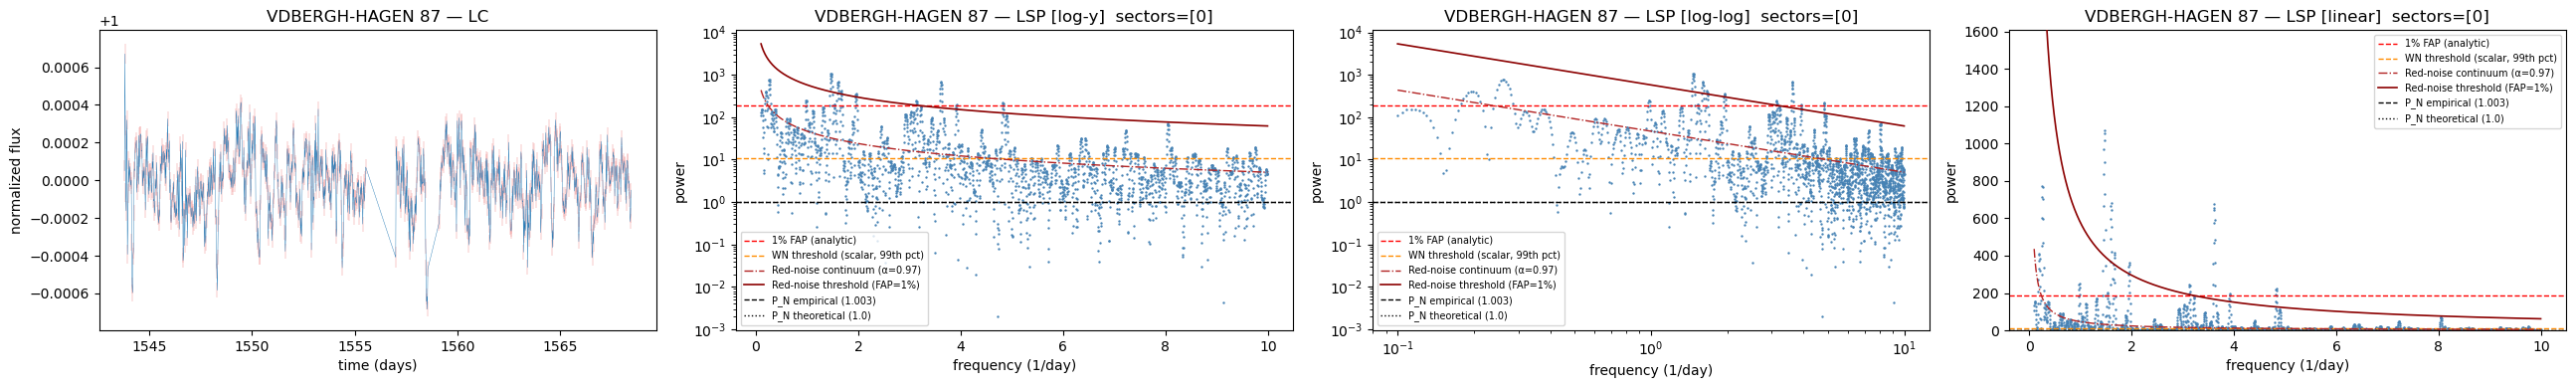

age 7.77


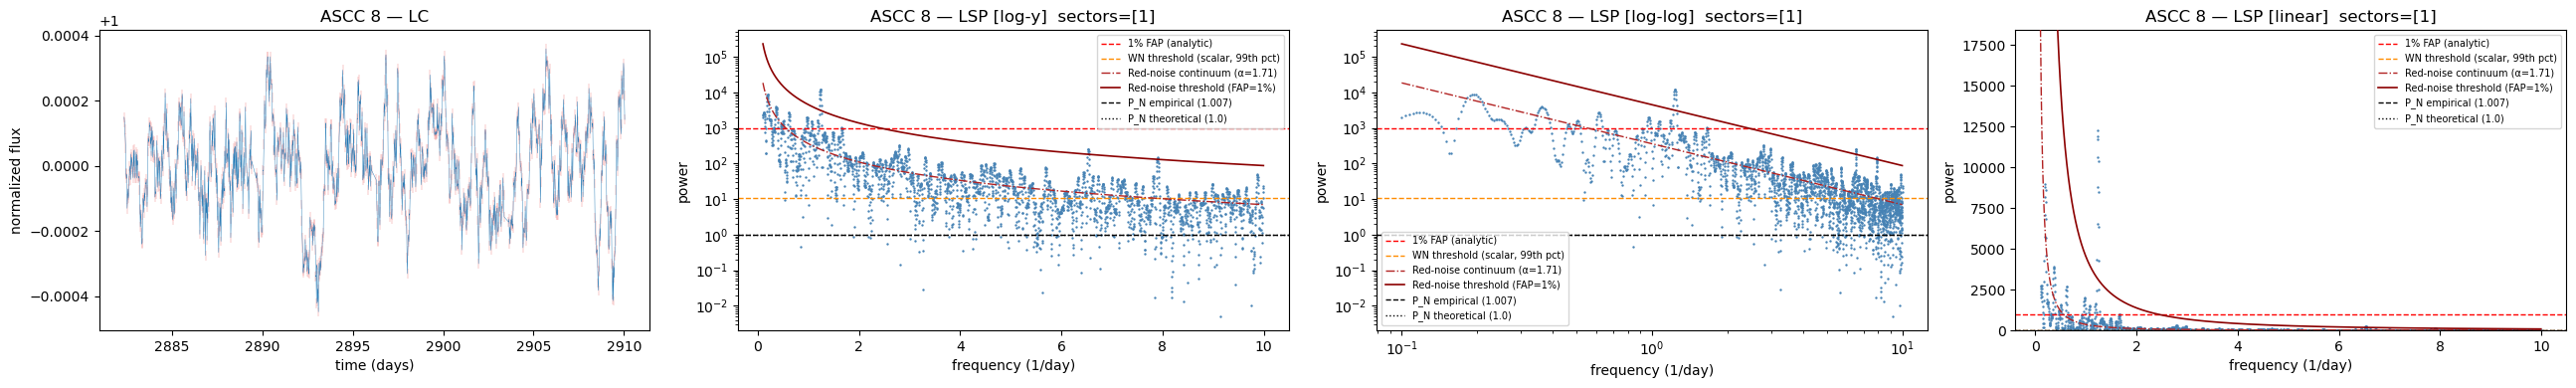

In [23]:

def plot_noise(row):
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(26, 4))
    
    ax1.errorbar(row['LC_t'], row['LC_flux'], row['LC_flux_err'], lw=0.3, ecolor='lightcoral')
    ax1.set(xlabel='time (days)', ylabel='normalized flux', title=f"{row['name']} — LC")
    
    freq  = row['LSP_freq']
    power = row['LSP_power']
    age = row['age']
    print('age', age)
    
    log10_N, alpha, P_N_empirical, P_N_theoretical = row['LSP_red_noise_params']
    P_model   = 10**log10_N * freq**(-alpha)
    n_freq    = len(freq)
    gamma     = -np.log(1 - 0.99**(1/n_freq))
    threshold = P_model * gamma
    
    for ax, xscale, yscale, title_suffix in [
      (ax2, 'linear', 'log',    'log-y'),
      (ax3, 'log',    'log',    'log-log'),
      (ax4, 'linear', 'linear', 'linear'),
    ]:
      #ax.plot(freq, power, lw=0.8, color='steelblue', zorder=2)
      ax.scatter(freq, power, s=0.5, color='steelblue', zorder=2)
      ax.axhline(row['LSP_FAP'], color='red', ls='--', lw=1,
                 label='1% FAP (analytic)')
      ax.axhline(row['LSP_WN_threshold'], color='darkorange', ls='--', lw=1,
                 label='WN threshold (scalar, 99th pct)')
      ax.plot(freq, P_model, color='firebrick', lw=1, ls='-.',
              label=f'Red-noise continuum (α={alpha:.2f})', zorder=3)
      ax.plot(freq, threshold, color='darkred', lw=1.2, ls='-',
              label='Red-noise threshold (FAP=1%)', zorder=3)
      ax.axhline(P_N_empirical, color='black', ls='--', lw=1,
                 label=f'P_N empirical ({P_N_empirical:.3f})')
      ax.axhline(P_N_theoretical, color='black', ls=':', lw=1,
                 label=f'P_N theoretical ({P_N_theoretical:.1f})')
      ax.set(xlabel='frequency (1/day)', ylabel='power',
             xscale=xscale, yscale=yscale,
             title=f"{row['name']} — LSP [{title_suffix}]  sectors={row['sectors']}")
      ax.legend(fontsize=7)
      if title_suffix == 'linear':
          ax.set_ylim(0, float(np.max(power)*1.5))
    
    plt.tight_layout()
    plt.show()



# Quick sanity check: plot the LC and LSP of the first row

# row = table.iloc[-1]

# plot_noise(row)

# #test_table = table.iloc[0:20]
# test_table = table[
#     (table["name"].isin(['BERKELEY 83', 'CZERNIK 13', 'KMHK1378'])) & 
#     (table["n_sectors"] == 1)     
# ]
# row = test_table.iloc[-1]

# plot_noise(row)


for i in range(0, len(table), len(table)//10):
    row = table.iloc[i]
    plot_noise(row)


In [14]:
# Empirical noise floor from the actual LSP at high frequencies
freqs = row['LSP_freq']
power = row['LSP_power']

high_freq_mask = freqs > 5  # well above any astrophysical signal
empirical_floor = np.median(power[high_freq_mask])


In [54]:
1/row['LSP_freq']

array([10.        ,  9.58786881,  9.20836344, ...,  0.10013549,
        0.10009241,  0.10004936], shape=(2303,))

In [20]:
table[table['name']=='BERKELEY 83']

,name,age,origin,sectors,n_sectors,cadence,LC_t,LC_flux,LC_flux_err,LSP_freq,LSP_power,LSP_FAP,LSP_WN_threshold,LSP_red_noise_params,intrinsic_std,intrinsic_rms,intrinsic_mad,n_bins_used,vn_ratio_gap_aware,stetson_j_gap_aware
81,BERKELEY 83,8.685,MW,[3],1,10.0,"[2797.1184312364835, 2797.139264609154, 2797.1...","[0.9997786177755194, 0.9995360553482615, 0.999...","[5.0901181273058466e-05, 5.090374355491446e-05...","[0.1, 0.10368479333427114, 0.10736958666854227...","[13.6147905872492, 15.96102950989205, 19.30395...",14.016199,11.618302,"(1.9390017242179685, 1.646307548651209, 1.0062...",0.000339,0.000339,0.000345,1254.0,6.448318,4.612215


psd, unweighted high-freq median: 0.000000
  Baluev: 1.398513e+01, Bootstrap: 1.160443e-06
psd, weighted high-freq median: 1.685060
  Baluev: 1.398605e+01, Bootstrap: 4.003953e+02
standard, unweighted high-freq median: 0.000092
  Baluev: 2.280492e-02, Bootstrap: 2.151894e-02
standard, weighted high-freq median: 0.000094
  Baluev: 2.280641e-02, Bootstrap: 2.159493e-02


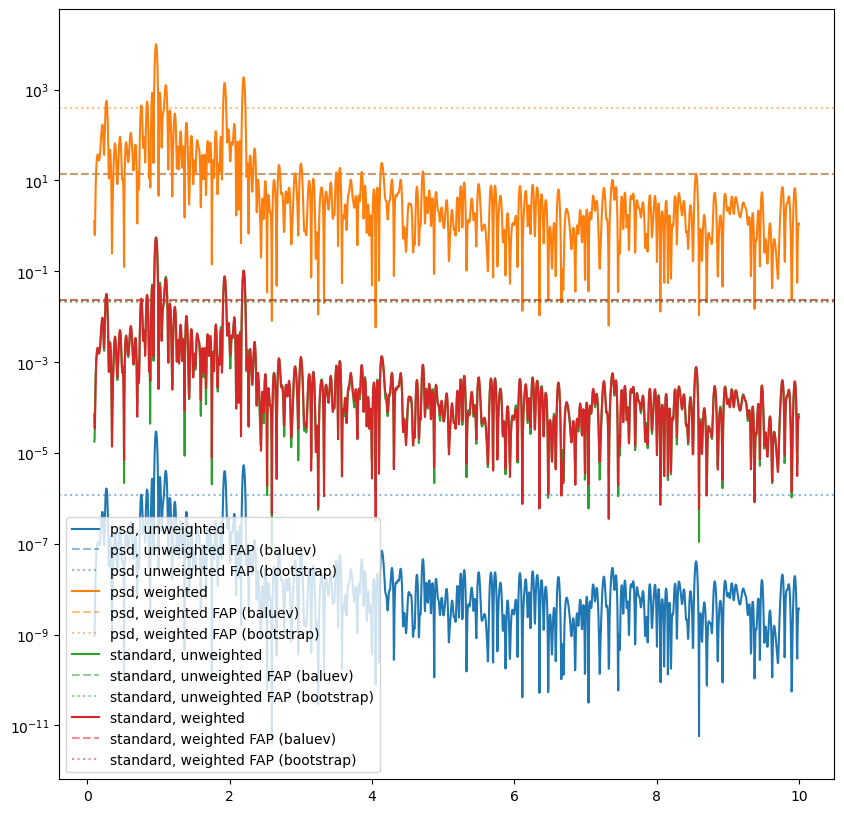

In [10]:
row = table[table['name']=='BERKELEY 83'].iloc[0]
t = row['LC_t']
flux = row['LC_flux']
err = row['LC_flux_err']
freqs = row['LSP_freq']

from astropy.timeseries import LombScargle

plt.figure(figsize=(10, 10))

configs = [
    ('psd, unweighted', 'psd', None),
    ('psd, weighted', 'psd', err),
    ('standard, unweighted', 'standard', None),
    ('standard, weighted', 'standard', err),
]

for label, norm, dy in configs:
    if dy is not None:
        ls = LombScargle(t, flux, dy, normalization=norm)
    else:
        ls = LombScargle(t, flux, normalization=norm)
    power = ls.power(freqs)
    print(f"{label} high-freq median: {np.median(power[freqs>7]):.6f}")
    line, = plt.plot(freqs, power, label=label)

    fap_baluev = ls.false_alarm_level(0.01, method='baluev')
    fap_bootstrap = ls.false_alarm_level(0.01, method='bootstrap', method_kwds={'n_bootstraps': 1000})
    print(f"  Baluev: {fap_baluev:.6e}, Bootstrap: {fap_bootstrap:.6e}")

    color = line.get_color()
    plt.axhline(fap_baluev, color=color, linestyle='--', alpha=0.5, label=f'{label} FAP (baluev)')
    plt.axhline(fap_bootstrap, color=color, linestyle=':', alpha=0.5, label=f'{label} FAP (bootstrap)')

plt.yscale('log')
plt.legend()

In [27]:
P_N_theory-P_N_true

0.0

## Step 3 — Summary statistics

In [11]:
%%time 
from table_pipeline.summary_stats import add_variability_metrics

add_variability_metrics(table)

stat_cols = ['intrinsic_std', 'intrinsic_rms', 'intrinsic_mad',
             'n_bins_used', 'vn_ratio_gap_aware', 'stetson_j_gap_aware']
table[stat_cols].describe()

[add_variability_metrics] processing 348 rows
[add_variability_metrics] done  |  ok=348  skipped=0  failed=0
CPU times: user 157 ms, sys: 0 ns, total: 157 ms
Wall time: 159 ms


,intrinsic_std,intrinsic_rms,intrinsic_mad,n_bins_used,vn_ratio_gap_aware,stetson_j_gap_aware
count,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,0.000515,0.000517,0.000488,1134.034483,3.743221,3.909664
std,0.000715,0.000717,0.000740,111.679291,5.185410,8.982722
min,0.000000,0.000000,0.000000,627.000000,0.487922,-0.011038
25%,0.000133,0.000133,0.000109,1116.000000,0.957431,0.482609
50%,0.000251,0.000253,0.000220,1145.000000,1.971465,1.749810
75%,0.000602,0.000603,0.000602,1190.000000,4.492518,3.726803
max,0.005842,0.005843,0.007452,1305.000000,47.076463,109.638097


## Step 4 — GP pipeline

Fit a multi-component SHO Gaussian Process to each row using the pre-computed LSP.
Results are stored in the table as `gp_result` (GPFitResult object) plus derived
columns for spectral statistics.

In [24]:
# test_table = table.iloc[0:20]
# test_table

test_table = table[
    (table["name"].isin(['BERKELEY 83', 'CZERNIK 13', 'KMHK1378'])) & 
    (table["n_sectors"] == 1)     
]
test_table


,name,age,origin,sectors,n_sectors,cadence,LC_t,LC_flux,LC_flux_err,LSP_freq,LSP_power,LSP_FAP,LSP_WN_threshold,LSP_red_noise_params
136,BERKELEY 83,8.685,MW,[2],1,10.00,"[2769.9167884451695, 2769.937622284224, 2769.9...","[1.0000644070316689, 1.000259509204112, 1.0001...","[3.5818390179752516e-05, 3.58181224456102e-05,...","[0.10151466853077548, 0.10659040195731426, 0.1...","[2.1123785339994368, 1.3751820261648093, 2.512...",324.300404,11.349601,"(1.831080710128704, 1.2292820168484164, 1.0046..."
47,CZERNIK 13,6.855,MW,[1],1,3.33,"[2882.344779634025, 2882.365613418642, 2882.38...","[0.9995883317210302, 0.9993124665835396, 0.999...","[4.5992626035832545e-05, 4.5905175425423904e-0...","[0.1, 0.10361080296294185, 0.1072216059258837,...","[7.280005236426681, 11.800343386742798, 17.874...",4806.021930,10.836590,"(2.628891739451154, 1.7616262827661682, 1.0073..."
3938,KMHK1378,7.400,LMC,[3],1,10.00,"[2036.2889686851177, 2036.3098023183538, 2036....","[0.9980577063289796, 0.9993860209982212, 0.999...","[0.0002878875791908263, 0.00028795926634817736...","[0.1, 0.10429846501658423, 0.10859693003316846...","[6.209478830081039, 7.945107650172328, 9.80284...",446.689473,11.427351,"(1.1577391366746532, 0.6308883629658367, 1.006..."


In [13]:
print('hi')

hi


[add_gp_fits] 10 clusters, 10 rows
Found 6 significant peak(s); fitting up to 6 component(s).
  Peak 1: period=0.455 d, power=6139.7985
  Peak 2: period=0.912 d, power=2516.5513
  Peak 3: period=0.484 d, power=1782.2581
  Peak 4: period=0.520 d, power=1413.5758
  Peak 5: period=0.430 d, power=512.4858
  Peak 6: period=0.291 d, power=273.8349


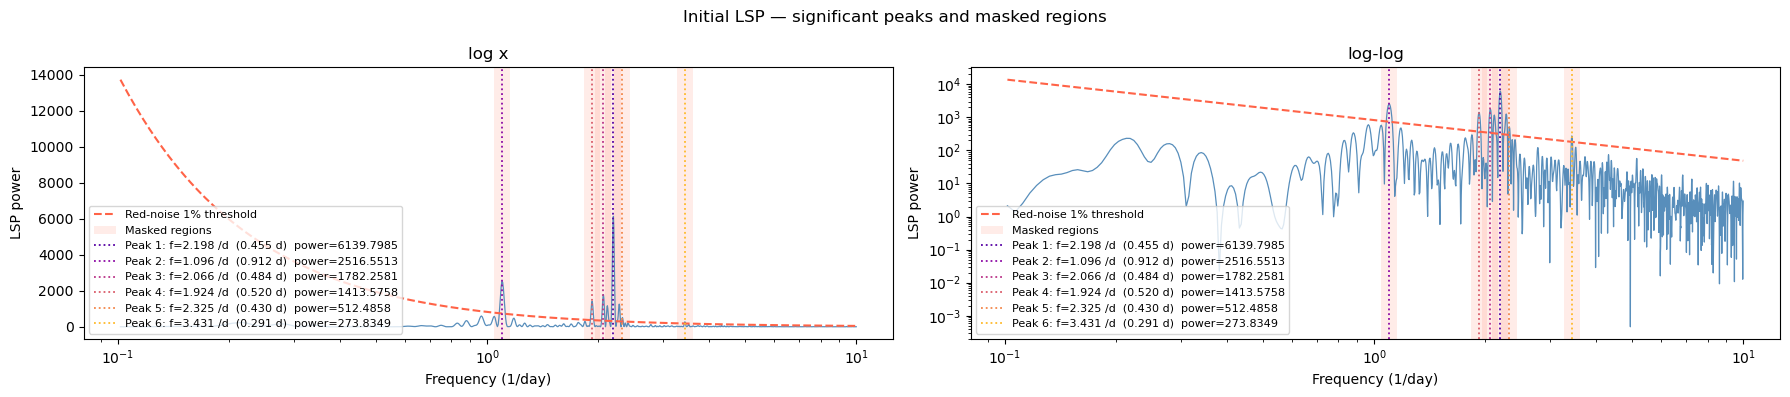

Fitting 6-component model...
  Fit 6 component(s): 9.6 s
  6 component(s): periods=['0.455', '0.939', '0.455', '0.486', '0.518', '0.265'] d, BIC=-14762.4

BIC summary (all models):
  m=6: BIC=-14762.4  <- best

Best model: 6 component(s) (BIC=-14762.4)
Total: 10.0 s
  [1/10] BERKELEY 83  (MW)  → 1 combo(s)  max_BIC=-14762.4
Found 10 significant peak(s); fitting up to 10 component(s).
  Peak 1: period=0.545 d, power=58485.2245
  Peak 2: period=0.595 d, power=23179.7677
  Peak 3: period=0.475 d, power=8908.8700
  Peak 4: period=0.517 d, power=8035.5653
  Peak 5: period=0.906 d, power=8532.2327
  Peak 6: period=0.640 d, power=6413.6546
  Peak 7: period=0.112 d, power=292.5352
  Peak 8: period=0.149 d, power=346.1134
  Peak 9: period=0.284 d, power=609.7395
  Peak 10: period=0.107 d, power=108.7660


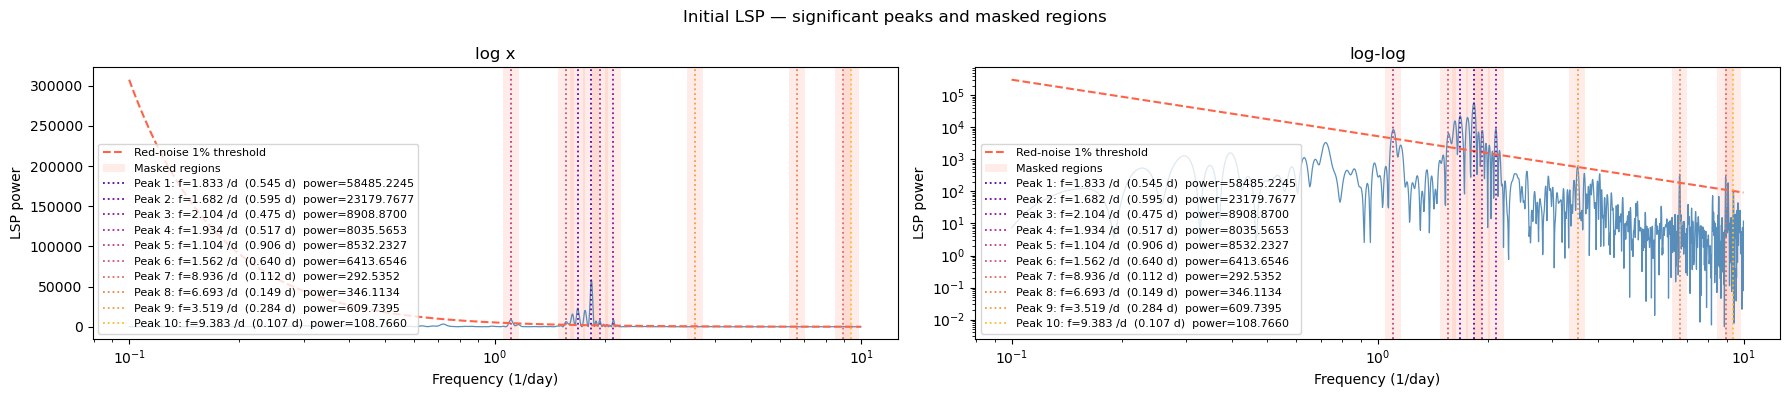

Fitting 10-component model...
  Fit 10 component(s): 13.3 s
  10 component(s): periods=['0.203', '1.069', '0.149', '0.207', '0.557', '1.389', '0.083', '3.326', '0.904', '0.083'] d, BIC=-15227.5

BIC summary (all models):
  m=10: BIC=-15227.5  <- best

Best model: 10 component(s) (BIC=-15227.5)
Total: 13.7 s
  [2/10] CZERNIK 13  (MW)  → 1 combo(s)  max_BIC=-15227.5
Found 9 significant peak(s); fitting up to 9 component(s).
  Peak 1: period=0.350 d, power=16617.7258
  Peak 2: period=0.471 d, power=2293.4814
  Peak 3: period=0.201 d, power=332.4922
  Peak 4: period=0.333 d, power=336.6293
  Peak 5: period=0.369 d, power=312.5654
  Peak 6: period=0.175 d, power=181.6460
  Peak 7: period=0.117 d, power=68.6076
  Peak 8: period=0.316 d, power=98.2406
  Peak 9: period=0.392 d, power=102.8034


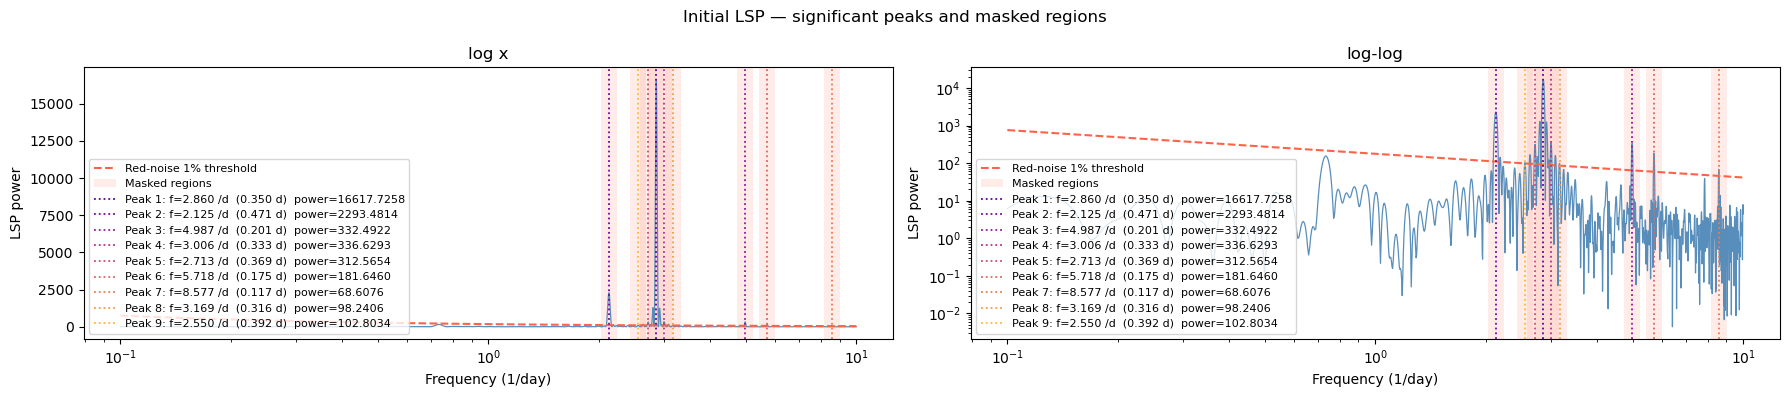

Fitting 9-component model...
  Fit 9 component(s): 21.3 s
  9 component(s): periods=['0.350', '0.471', '1.718', '0.341', '0.349', '0.201', '0.175', '1.238', '0.237'] d, BIC=-14004.4

BIC summary (all models):
  m=9: BIC=-14004.4  <- best

Best model: 9 component(s) (BIC=-14004.4)
Total: 21.8 s
  [3/10] KMHK1378  (LMC)  → 1 combo(s)  max_BIC=-14004.4
  No significant LSP peaks found — fallback: 1-component SHO (P_seed=1 d, Q_seed=1).
  Fallback fit: period=0.757 d, BIC=-10880.8  (1.5 s)
  [4/10] BERKELEY 85  (MW)  → 1 combo(s)  max_BIC=-10880.8
Found 4 significant peak(s); fitting up to 4 component(s).
  Peak 1: period=1.587 d, power=700.1380
  Peak 2: period=1.462 d, power=309.7345
  Peak 3: period=0.788 d, power=136.4703
  Peak 4: period=0.527 d, power=41.4782


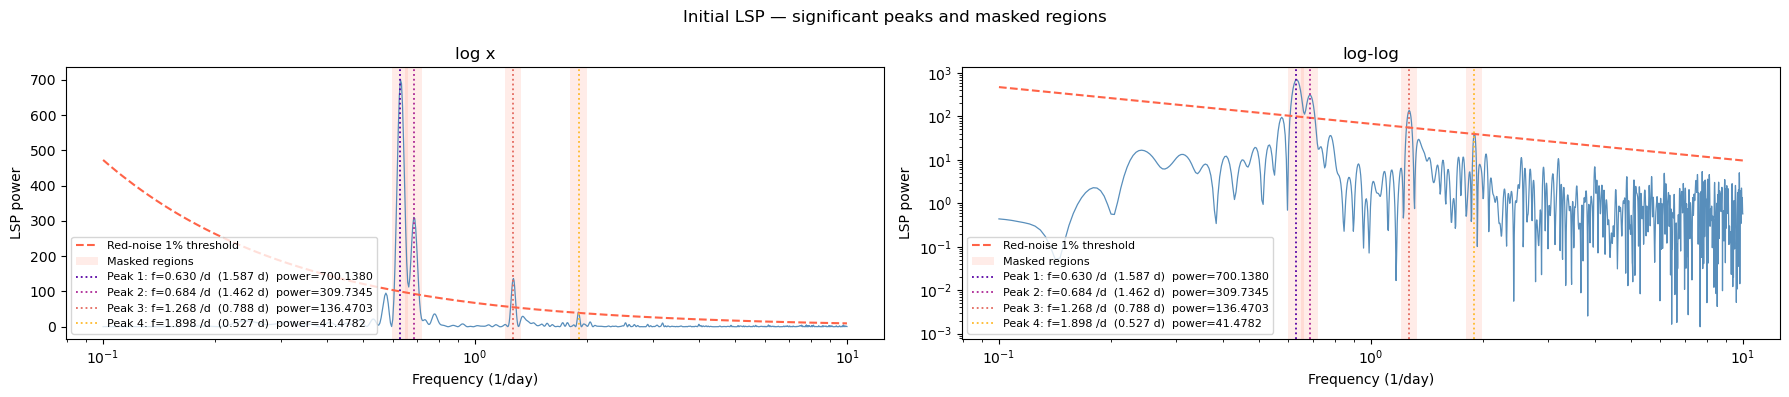

Fitting 4-component model...
  Fit 4 component(s): 5.3 s
  4 component(s): periods=['1.485', '1.583', '0.790', '0.513'] d, BIC=-14578.4

BIC summary (all models):
  m=4: BIC=-14578.4  <- best

Best model: 4 component(s) (BIC=-14578.4)
Total: 5.8 s
  [5/10] [RZ2005] 38  (SMC)  → 1 combo(s)  max_BIC=-14578.4
  No significant LSP peaks found — fallback: 1-component SHO (P_seed=1 d, Q_seed=1).
  Fallback fit: period=1.181 d, BIC=-16965.4  (1.2 s)
  [6/10] FSR 1645  (MW)  → 1 combo(s)  max_BIC=-16965.4
  No significant LSP peaks found — fallback: 1-component SHO (P_seed=1 d, Q_seed=1).
  Fallback fit: period=10.000 d, BIC=-15067.6  (0.6 s)
  [7/10] NGC2133  (LMC)  → 1 combo(s)  max_BIC=-15067.6
  No significant LSP peaks found — fallback: 1-component SHO (P_seed=1 d, Q_seed=1).
  Fallback fit: period=0.774 d, BIC=-15676.9  (0.9 s)
  [8/10] OGLE-CL SMC 53  (SMC)  → 1 combo(s)  max_BIC=-15676.9
Found 7 significant peak(s); fitting up to 7 component(s).
  Peak 1: period=0.680 d, power=1071.259

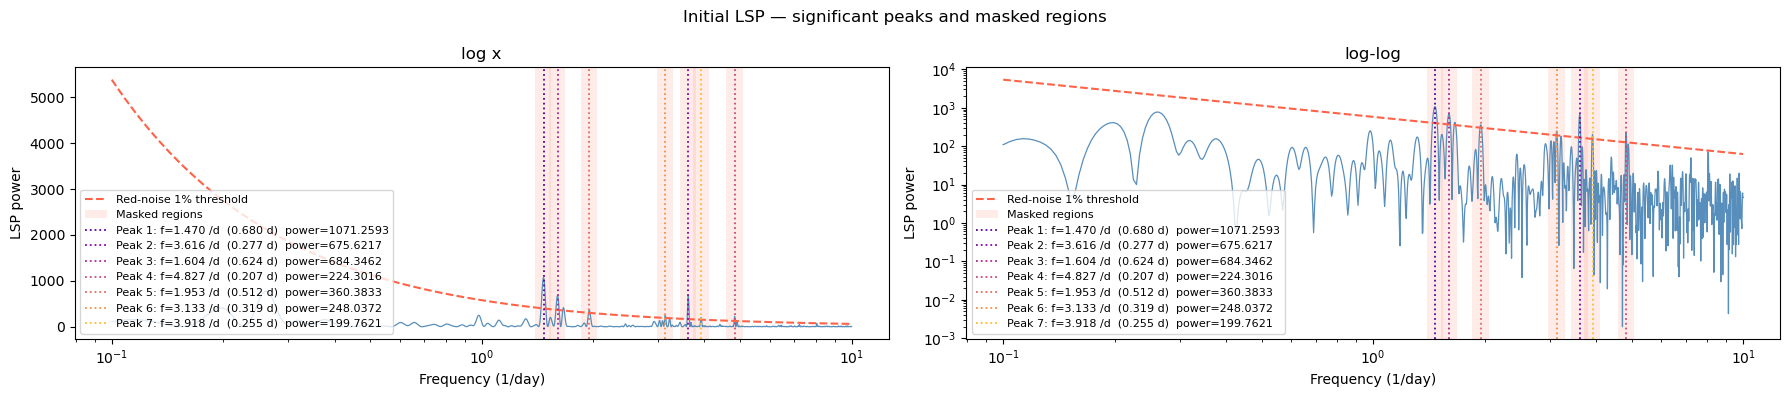

Fitting 7-component model...
  Fit 7 component(s): 33.7 s
  7 component(s): periods=['3.664', '0.276', '0.085', '0.206', '0.648', '0.319', '0.255'] d, BIC=-16663.1

BIC summary (all models):
  m=7: BIC=-16663.1  <- best

Best model: 7 component(s) (BIC=-16663.1)
Total: 34.2 s
  [9/10] VDBERGH-HAGEN 87  (MW)  → 1 combo(s)  max_BIC=-16663.1
Found 3 significant peak(s); fitting up to 3 component(s).
  Peak 1: period=0.811 d, power=12274.6466
  Peak 2: period=0.153 d, power=259.6184
  Peak 3: period=0.127 d, power=148.1892


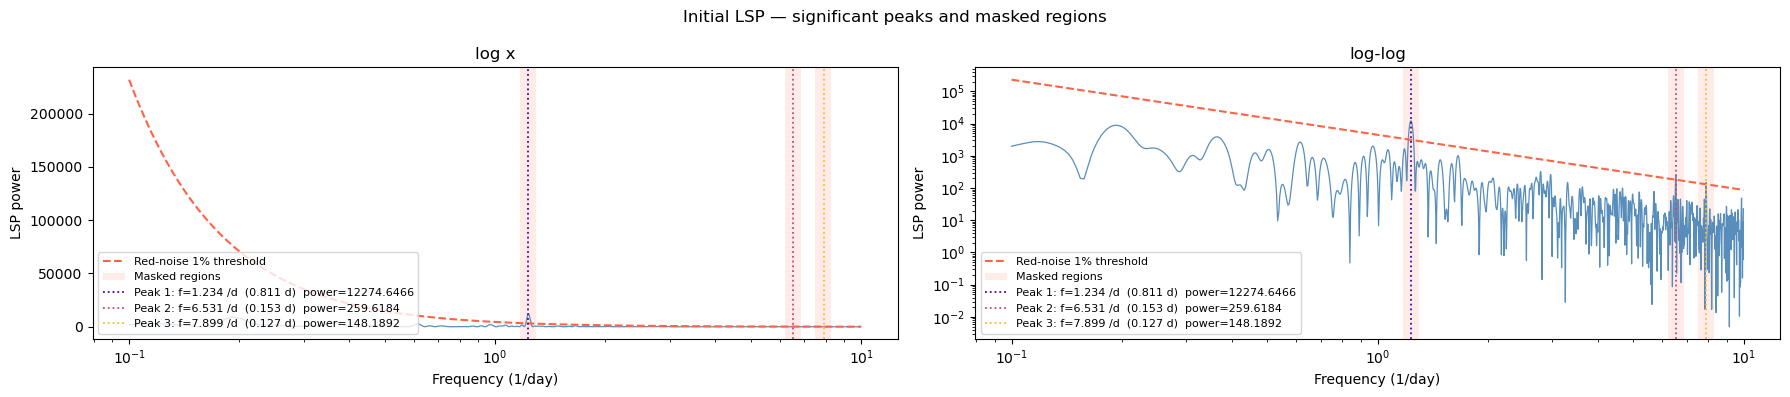

Fitting 3-component model...
  Fit 3 component(s): 3.7 s
  3 component(s): periods=['0.888', '0.095', '0.144'] d, BIC=-21634.2

BIC summary (all models):
  m=3: BIC=-21634.2  <- best

Best model: 3 component(s) (BIC=-21634.2)
Total: 4.2 s
  [10/10] ASCC 8  (MW)  → 1 combo(s)  max_BIC=-21634.2
[add_gp_fits] done  |  ok=10  null=0  failed=0
GP PSD spectral bands (log_band_powers[0] = lowest freq / longest period):
  [0]: 0.1000 - 0.1614 1/day  (6.20 - 10.00 d)
  [1]: 0.1614 - 0.2605 1/day  (3.84 - 6.20 d)
  [2]: 0.2605 - 0.4205 1/day  (2.38 - 3.84 d)
  [3]: 0.4205 - 0.6787 1/day  (1.47 - 2.38 d)
  [4]: 0.6787 - 1.0954 1/day  (0.91 - 1.47 d)
  [5]: 1.0954 - 1.7681 1/day  (0.57 - 0.91 d)
  [6]: 1.7681 - 2.8538 1/day  (0.35 - 0.57 d)
  [7]: 2.8538 - 4.6062 1/day  (0.22 - 0.35 d)
  [8]: 4.6062 - 7.4347 1/day  (0.13 - 0.22 d)
  [9]: 7.4347 - 12.0000 1/day  (0.08 - 0.13 d)
[add_gp_fits] saved 10 GPFitResult objects to gp_fit_data_test.pkl
GP columns added: ['gp_result', 'GP_freq', 'GP_PSD', 'G

In [61]:
from gp_pipeline.gp_table_io import add_gp_fits

add_gp_fits(
    table,
    save_path="gp_fit_data_test.pkl",
    freq_lim=(0.1, 12.0),   # 1/day; matches LSP_freq range
    n_bins=10, # number of bins in gp summary stats
    
    max_components=20,
    
    Q_min=0.51,
    Q_max=100.0,
    init_Q=5.0,    
    
    fit_full_only=True,              # set to True If you only want to fit the full n_peaks SHO components version of the model.
    debug_fitalln=True,              # True turns off early BIC stopping
    bic_improvement_threshold=10.0,  # How much BIC needs to improve by before early stopping kicks in

    threshold_mode='red_noise',
    harmonic_tolerance=0.05,
    harmonic_masking=False,

    verbose=2,
)

print("GP columns added:", [c for c in table.columns if c.startswith("gp") or c.startswith("GP")])

n_components=6  BIC=-14762.4  periods=[0.4551927540665298, 0.938699452799969, 0.4552219118430113, 0.485962837331933, 0.5179740766919657, 0.2651225275744797]
n_components=10  BIC=-15227.5  periods=[0.20295559393987245, 1.0688921500029767, 0.14888012376221885, 0.20678465222565603, 0.5566311431053614, 1.3888500894697566, 0.08333333333333333, 3.3255906884606667, 0.9037351970594961, 0.08333333333333333]
n_components=9  BIC=-14004.4  periods=[0.34961545982081277, 0.4713460693546612, 1.7175100899588878, 0.341189712364266, 0.34942671619165394, 0.20061938675467775, 0.1750029264187254, 1.2380519682988855, 0.23685341481515523]
n_components=1  BIC=-10880.8  periods=[0.7569776116666361]
n_components=4  BIC=-14578.4  periods=[1.4852860164308055, 1.5831480253857735, 0.7901321446342985, 0.5130083137959506]
n_components=1  BIC=-16965.4  periods=[1.1812077512987078]
n_components=1  BIC=-15067.6  periods=[10.000000000000002]
n_components=1  BIC=-15676.9  periods=[0.7744902491922532]
n_components=7  BIC=-

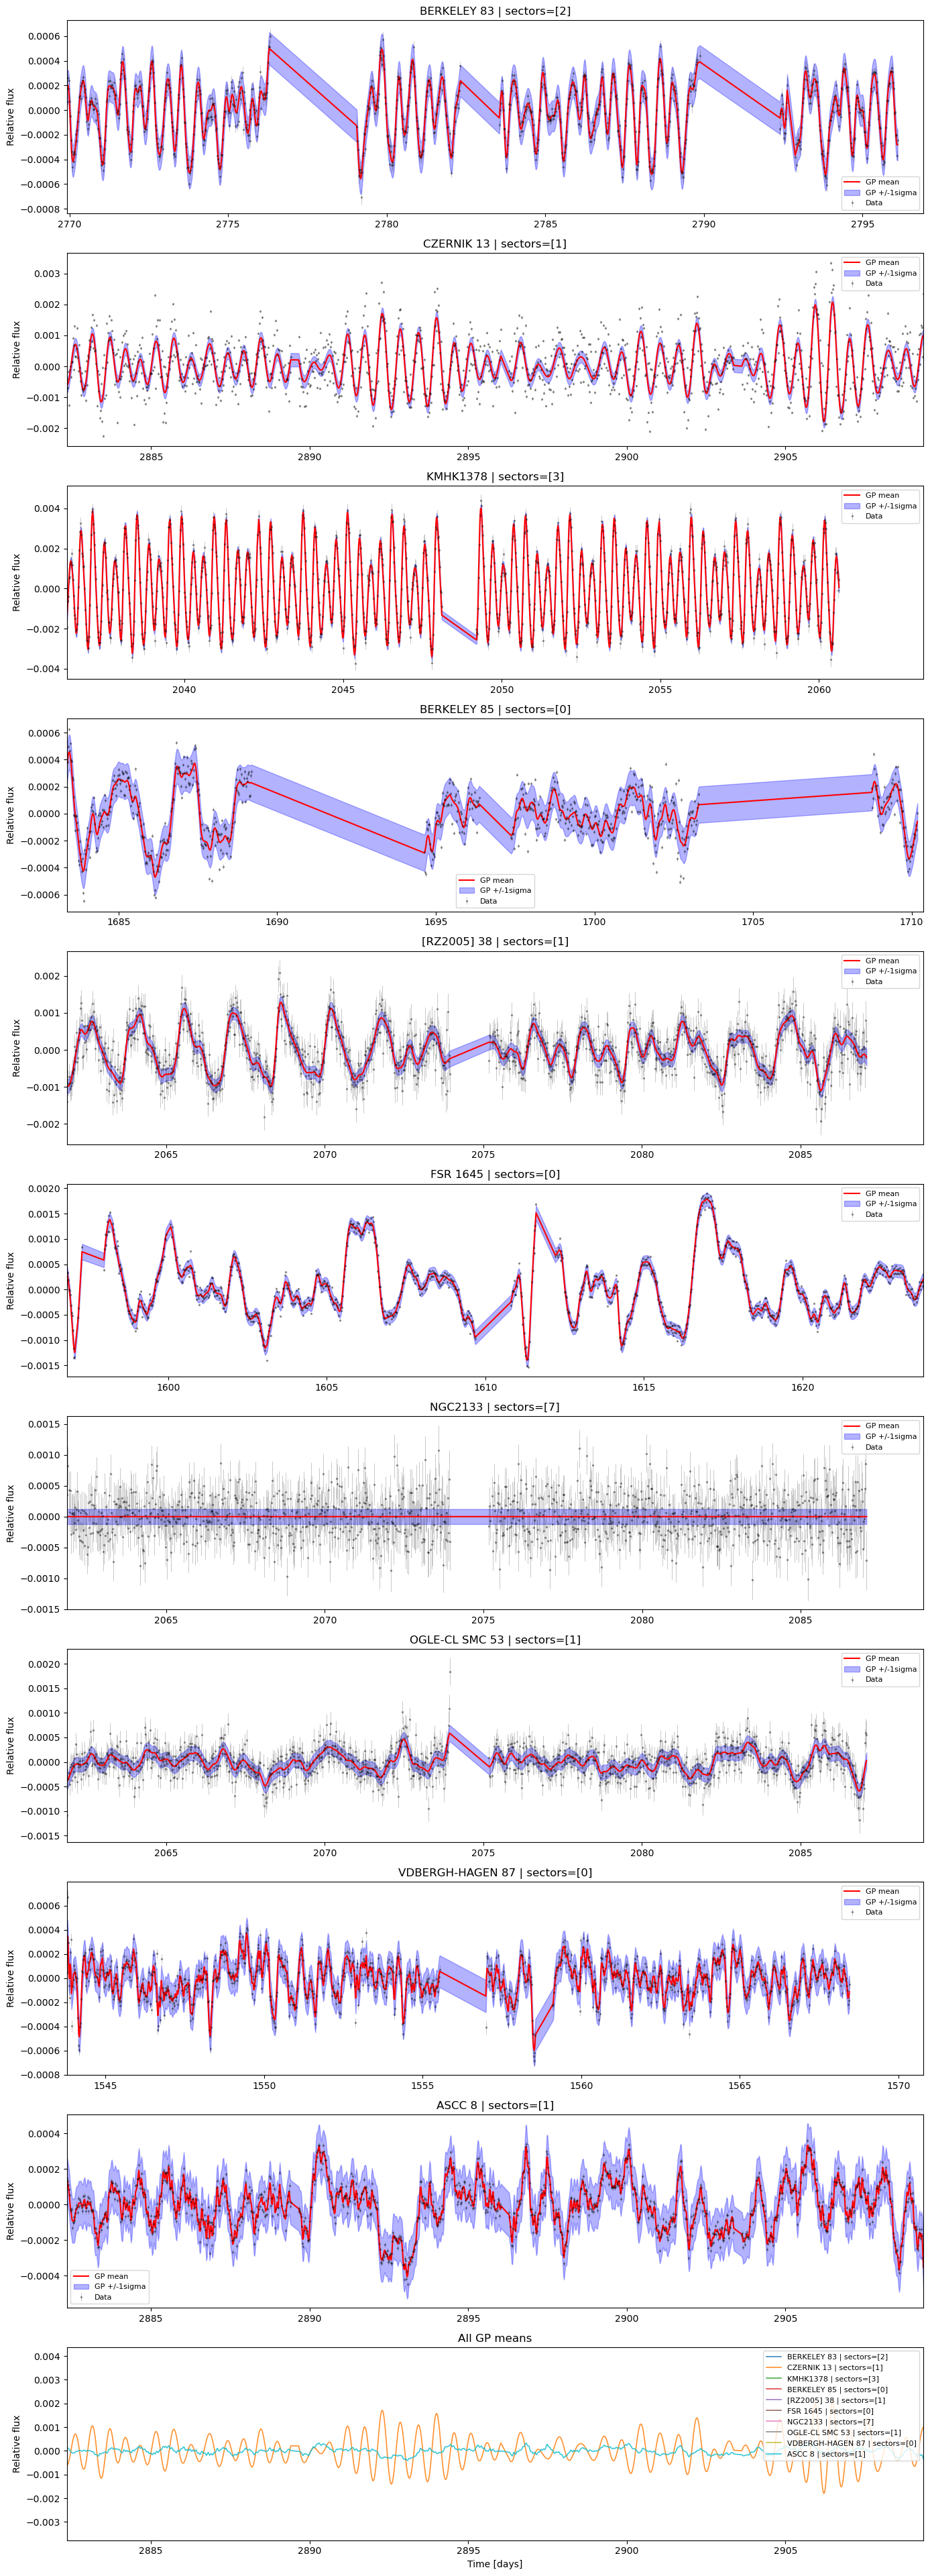

/astro/users/cgwill/TESS_Cluster_Age_ML/GenerateTable_CGW/gp_pipeline/visualize_gp_afterfit.py:50: RuntimeWarning: divide by zero encountered in divide
  First n rows : individual LC (data + GP mean +/-1sigma band), one per result.


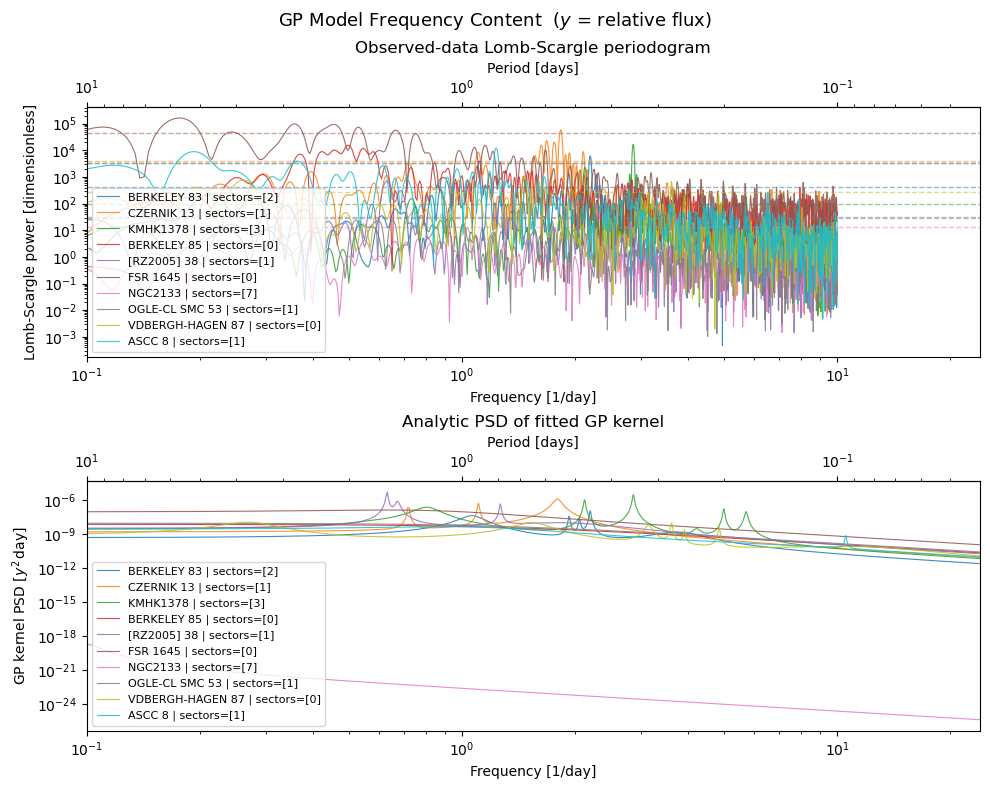

/astro/users/cgwill/TESS_Cluster_Age_ML/GenerateTable_CGW/gp_pipeline/visualize_gp_afterfit.py:64: RuntimeWarning: divide by zero encountered in divide
  n_rows = n + 1


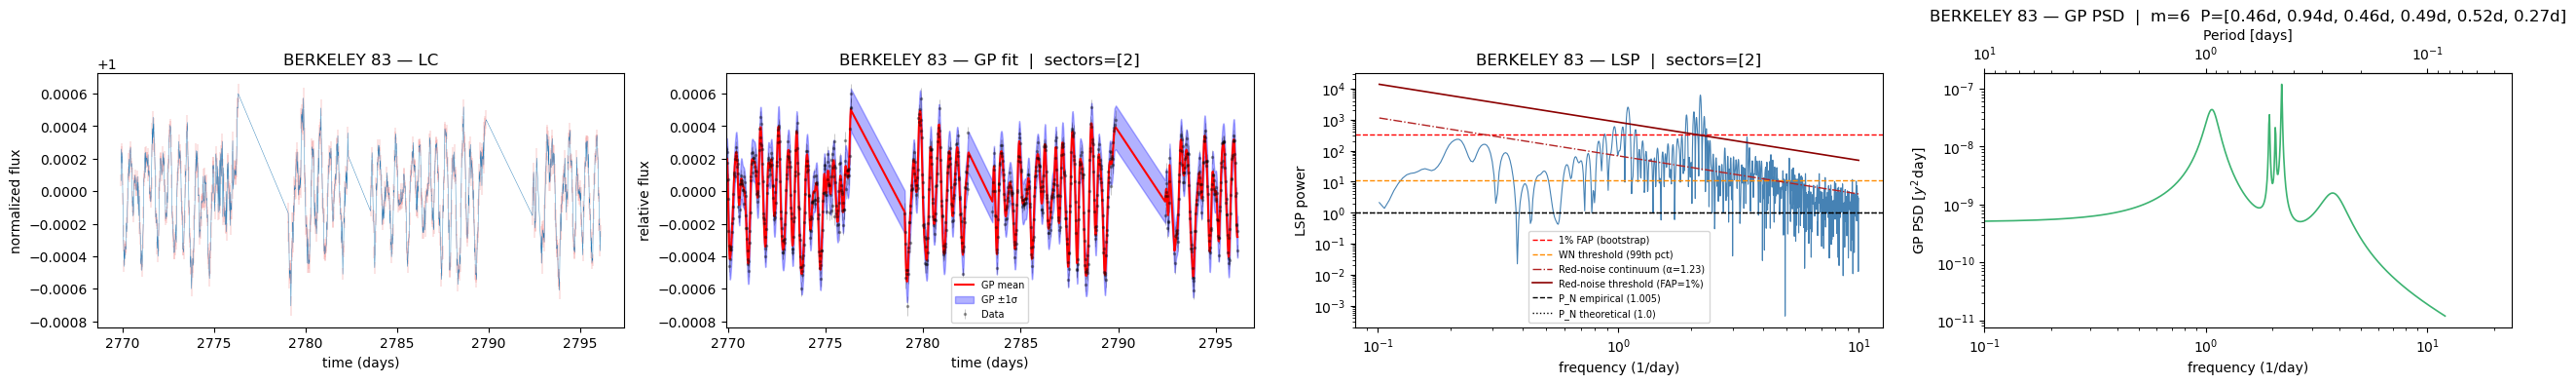

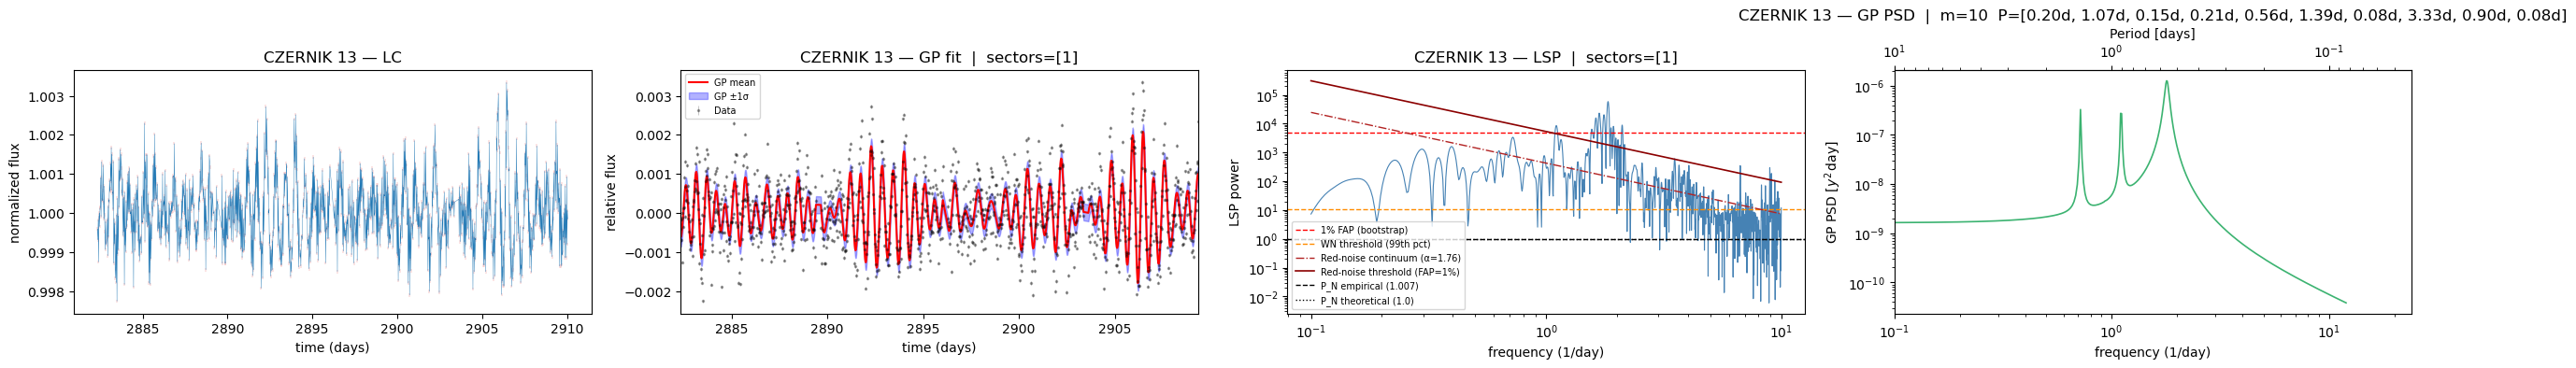

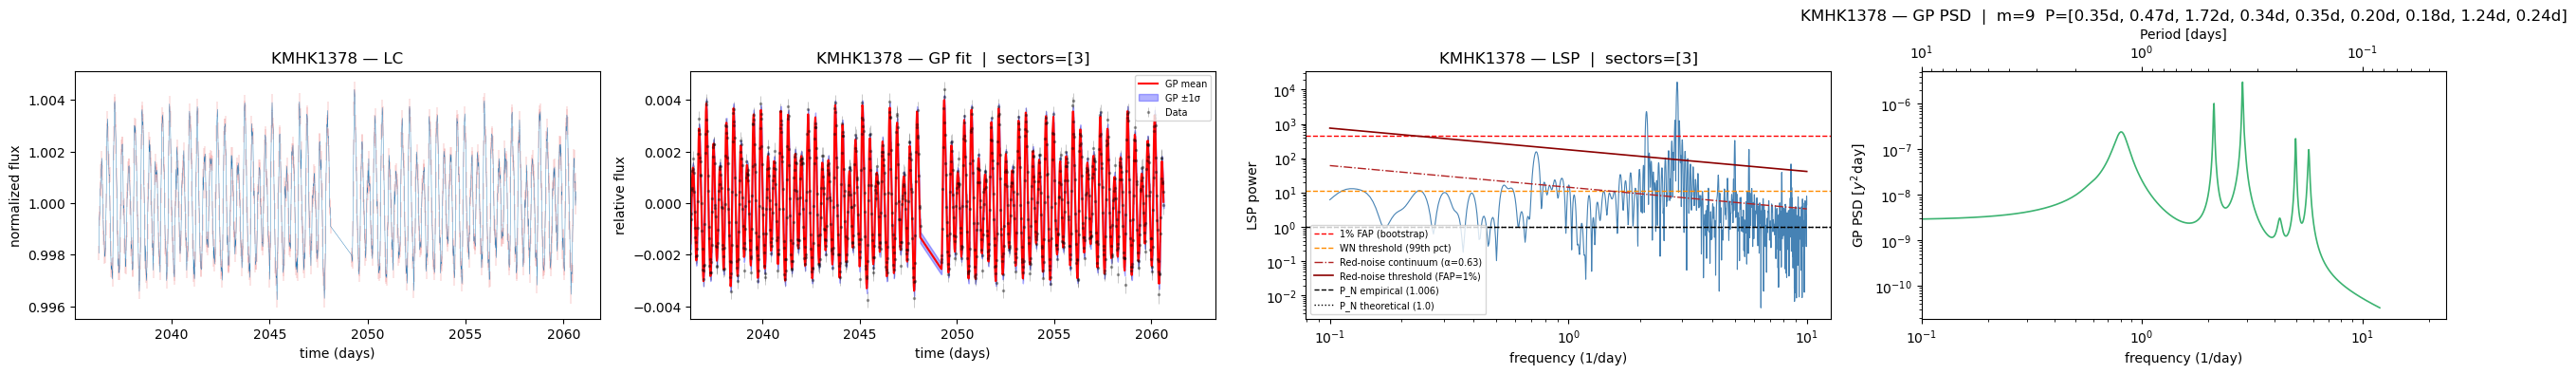

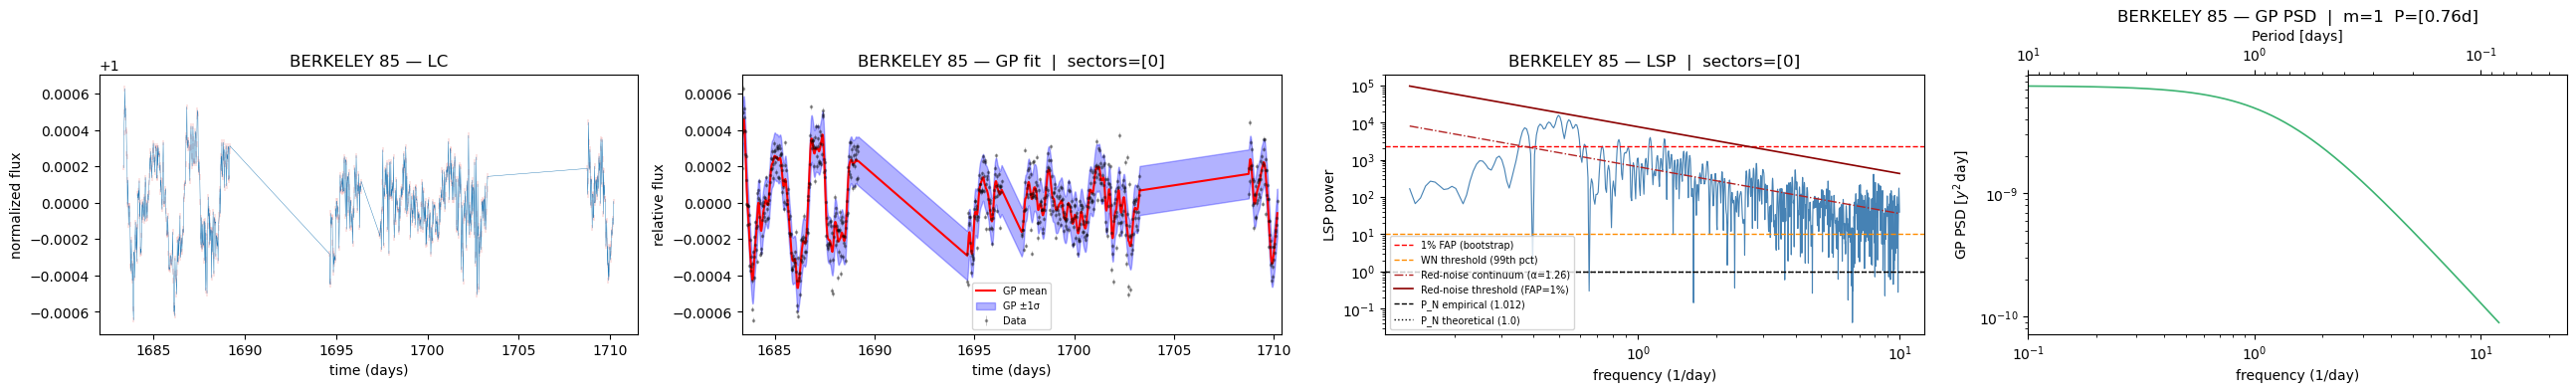

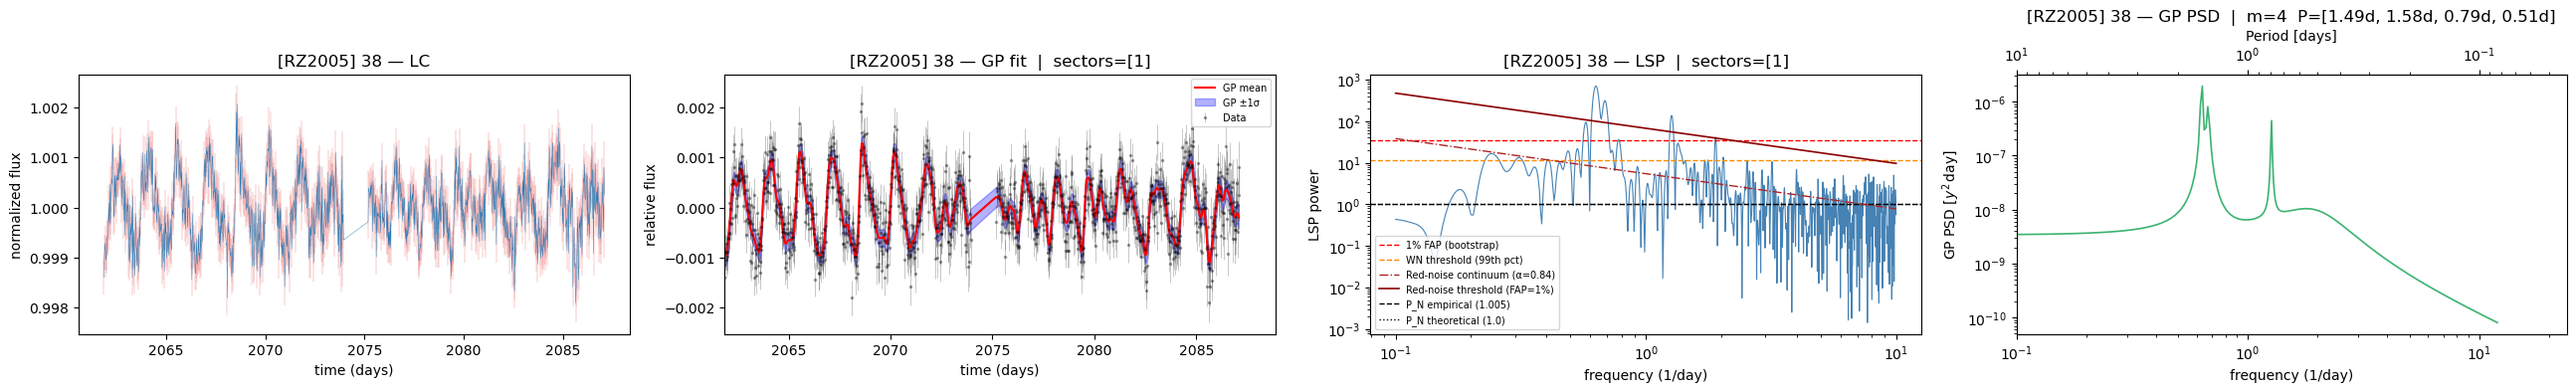

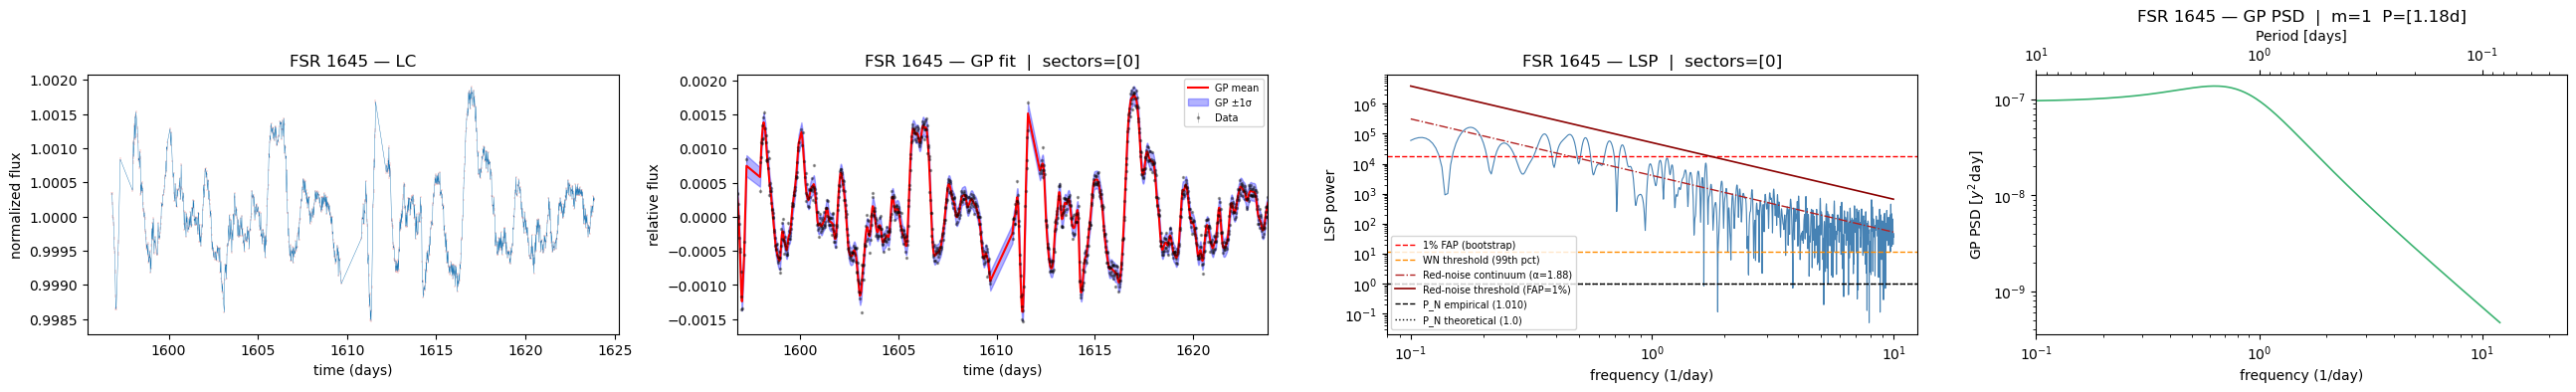

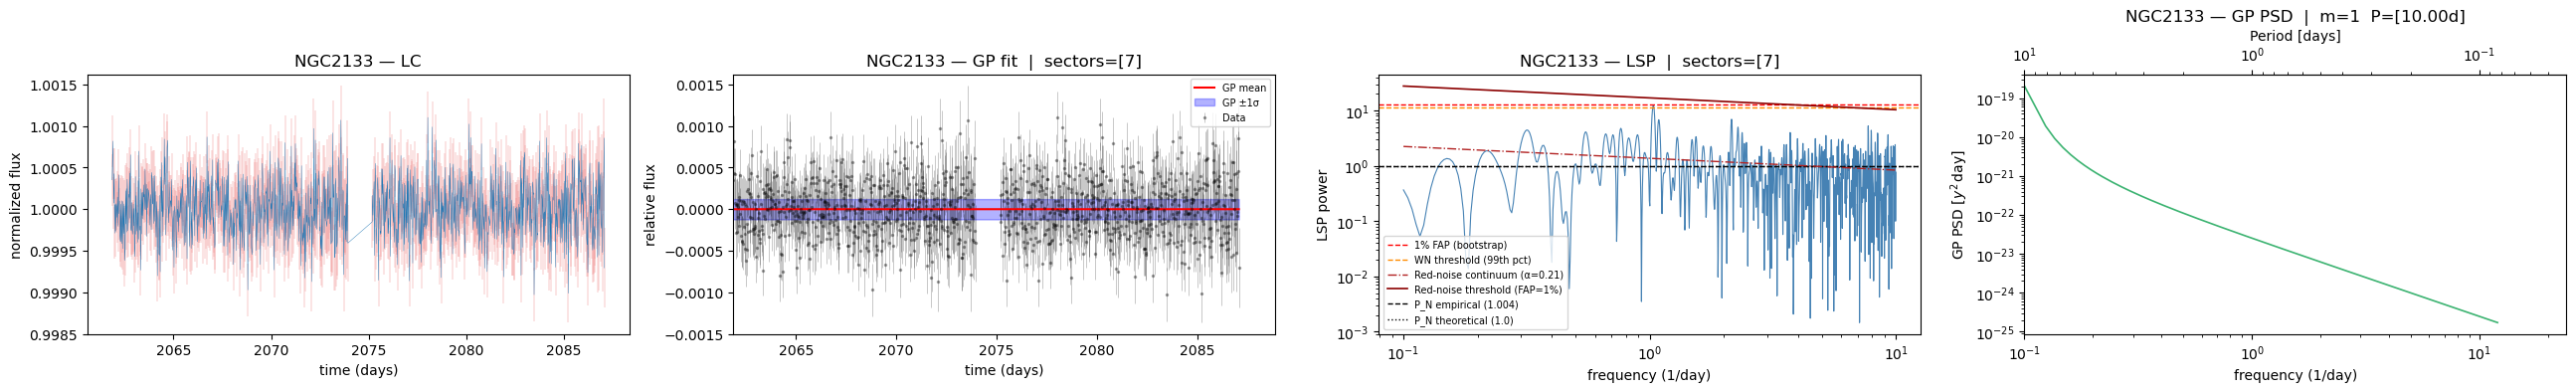

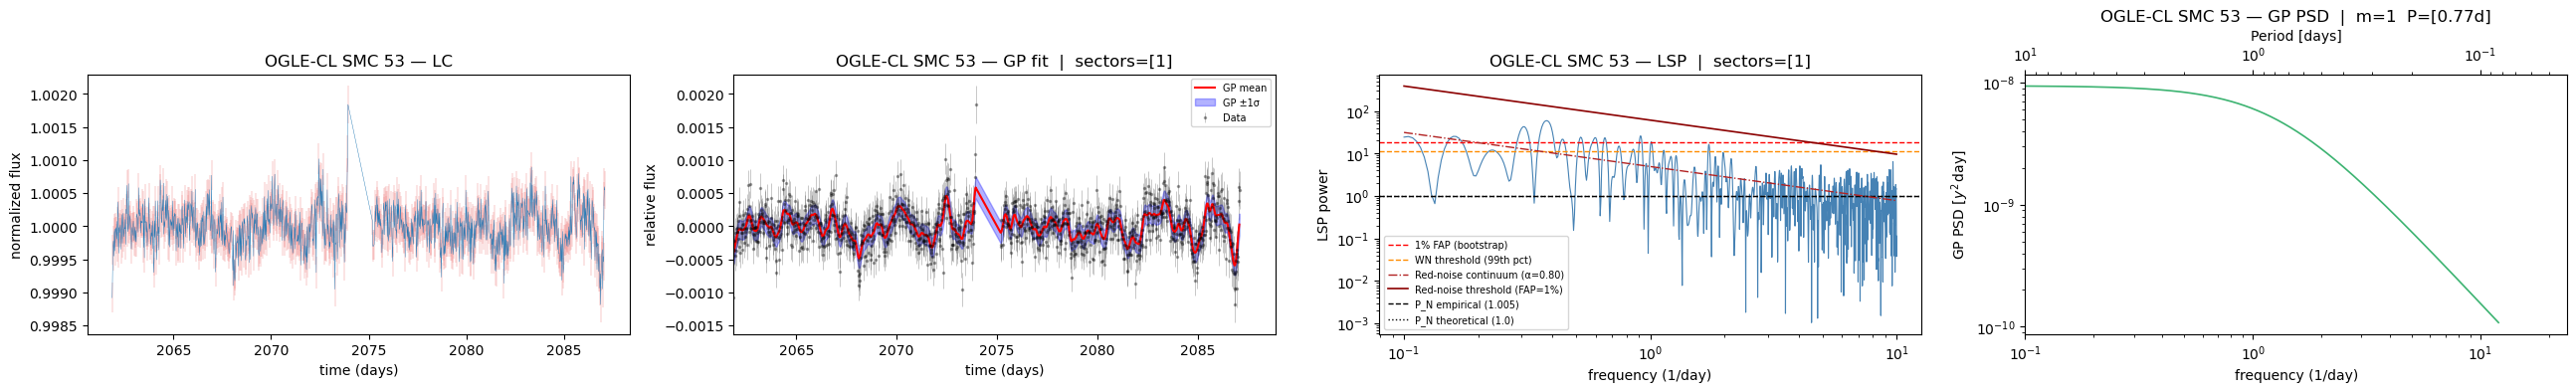

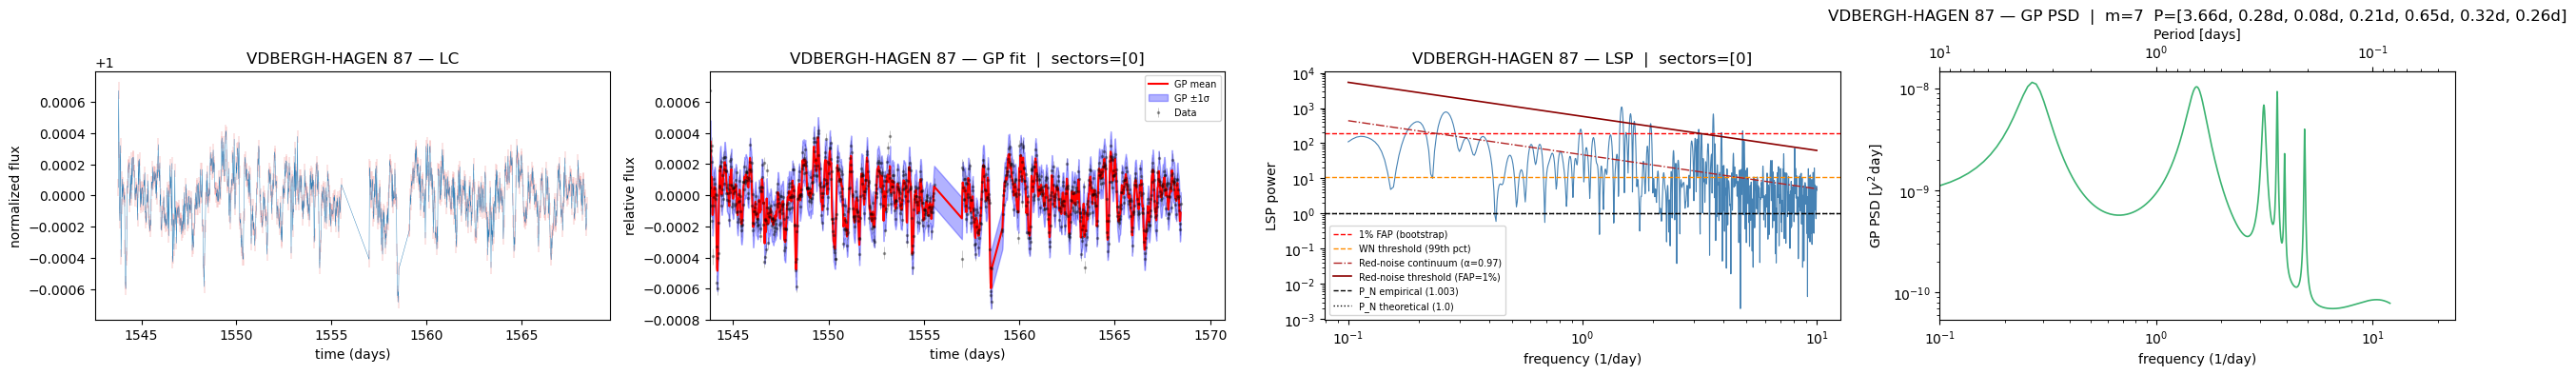

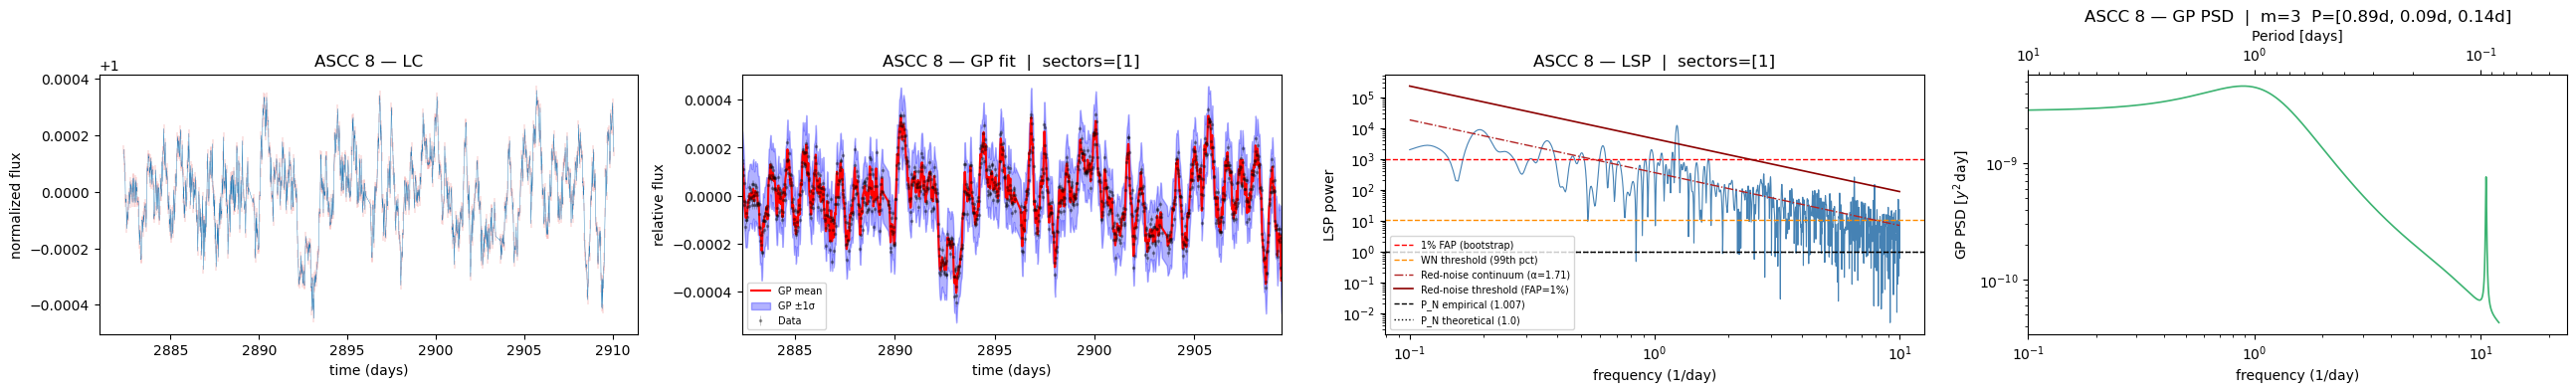

In [62]:
from gp_pipeline.gp_table_io import load_gp_results
from gp_pipeline.visualize_gp_afterfit import plot_gp_fit, plot_kspace, plot_noise_gp

for i in range(0, len(table)):
    row = table.iloc[i]
    result = row["gp_result"]
    if result is not None:
        print(f"n_components={result.n_components}  BIC={result.bic:.1f}  periods={result.periods}")
    else:
        print("No GP result for this row")

plot_gp_fit(table)
plot_kspace(table, log_y=True)
plot_noise_gp(table) 

## Step 5 — Save table

In [ ]:
table.to_pickle(OUTPUT)
print(f"Saved {len(table)} rows to {OUTPUT}")
print(f"Columns: {list(table.columns)}")

## Step 6 — Visualization examples

In [ ]:
from visualization.vis_lc import plot_cluster_lcs
from visualization.vis_periodogram import plot_cluster_lsp
from visualization.vis_statistics import plot_cluster_statistics, plot_clusters_comparison

example_name = table['name'].iloc[0]
print(f"Example cluster: {example_name}")

In [ ]:
# Raw sector LCs (reads directly from FITS file)
plot_cluster_lcs(table, example_name, lc_dir=LC_DIR)

In [ ]:
# LSP by n_sectors group
plot_cluster_lsp(table, example_name)

In [ ]:
# Summary statistics distribution by n_sectors
plot_cluster_statistics(table, example_name,
                        statistics_list=['intrinsic_std', 'intrinsic_rms',
                                         'vn_ratio_gap_aware', 'stetson_j_gap_aware'])

In [ ]:
# Cross-cluster comparison for n_sectors=1
plot_clusters_comparison(table, n_sectors=1, statistic='intrinsic_std')